# ___Summaries of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [2]:
library("ape")
library("phytools")
library("corHMM")
library("OUwie")
library("reshape2")
library("ggplot2")

source("../helpers.R")

Loading required package: maps

Loading required package: nloptr

Loading required package: GenSA

Loading required package: corpcor

Loading required package: geiger

Loading required package: RColorBrewer



In [3]:
options(repr.plot.width = 30, repr.plot.height = 12)

## ___Root diameter (RD)___
-----------------------

In [ ]:
load("./rdata/OU_RD_CD.RData") # rate.cat=1, null.model=FALSE
load("./rdata/OU_RD_CID.RData") # rate.cat=2, null.model=TRUE

# find out the AIC and AICc of all the models

# rate.cat=1, null.model=FALSE
models_CD_RD <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD, ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD,
                     SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD, SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

# rate.cat=2, null.model=TRUE
models_CID_RD <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID, ARDOUM=ARD_OUM_RD_CID, ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID,
                    SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID, SYMOUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)


# model averages
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

avg_models_CD_RD <- OUwie::getModelAvgParams(models_CD_RD, type = "AICc", force = FALSE)
avg_models_CID_RD <- OUwie::getModelAvgParams(models_CID_RD, type = "AICc", force = FALSE)

# look up to see what the BIC stuff is about
# https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC
# https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

In [ ]:
plot_df <- reshape2::melt(avg_models_CID_RD)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    facet_wrap(~variable, scales = "free")

In [ ]:
plot_df <- reshape2::melt(avg_models_CD_RD)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    facet_wrap(~variable, scales = "free")

In [ ]:
load("./rdata/OU_RD_CID_4states.RData")
load("./rdata/OU_RD_CD_4states.RData")

# rate.cat=1, null.model=FALSE
models_CD_RD_4states <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD,
                     ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD, SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD,
                     SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

# rate.cat=2, null.model=TRUE
models_CID_RD_4states <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID,
                      ARDOUM=ARD_OUM_RD_CID, ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID,
                      SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID, SYMOUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)

avg_models_CD_RD_4states <- OUwie::getModelAvgParams(models_CD_RD_4states, type = "AICc", force = FALSE)
avg_models_CID_RD_4states <- OUwie::getModelAvgParams(models_CID_RD_4states, type = "AICc", force = FALSE)

plot_df <- reshape2::melt(avg_models_CID_RD_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + 
    facet_wrap(~variable, scales = "free")

plot_df <- reshape2::melt(avg_models_CD_RD_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    facet_wrap(~variable, scales = "free")

In [4]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (NOT LOG TRANSFORMED)
# WITH 7 MYCORRHIZAL STATES
#------------------------------------------------------------------------------------------------------------------------------------


load("../rdata/OU_RD_CD_1005sp.RData")
load("../rdata/OU_RD_CID_1005sp.RData")

models_CD_RD_1005sp <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD,
                              ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD, SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD,
                              SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

models_CID_RD_1005sp <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID, ARDOUM=ARD_OUM_RD_CID,
                               ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID, SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID,
                               SYM_OUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)

# wrapping the expression inside invisible() did not work.
capture.output(avg_models_CD_RD_1005sp <- OUwie::getModelAvgParams(models_CD_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_RD_1005sp <- OUwie::getModelAvgParams(models_CID_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(model.list = models_CD_RD_1005sp, type = "AICc")
OUwie::getModelTable(model.list = models_CID_RD_1005sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EROUM,10,115.95774,-262.3115,381.40216,-211.69415,0.00000,9.949291e-01
EROUMA,16,-187.02579,-262.3209,78.28670,406.60220,618.29635,5.450629e-135
EROUMV,16,116.84304,-262.2966,382.56272,-201.13548,10.55867,5.069979e-03
EROUMVA,22,-215.70147,-264.5613,42.09538,476.43350,688.12765,3.739147e-150
ARDOUM,51,31.45702,-238.3359,273.13968,44.65154,256.34569,2.152942e-56
ARDOUMA,57,-187.82765,-249.3991,61.98504,496.63735,708.33150,1.533067e-154
ARDOUMV,57,32.82636,-238.1989,266.00921,55.32932,267.02347,1.033672e-58
ARDOUMVA,63,-204.05384,-245.0047,39.58153,542.67728,754.37143,1.542119e-164
SYMOUM,30,122.88075,-240.2156,366.39338,-183.85185,27.84230,8.951864e-07


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EROUM,8,105.57300,-262.3151,371.18507,-195.00142,0.000000,4.842426e-01
EROUMA,9,105.91936,-262.3385,371.57221,-193.65781,1.343609,2.473443e-01
EROUMV,9,105.97273,-262.3017,371.62537,-193.76455,1.236868,2.609038e-01
EROUMVA,10,103.44493,-262.4792,368.07729,-186.66853,8.332892,7.509283e-03
ARDOUM,90,-117.39833,-300.2429,165.24502,432.71788,627.719299,2.385333e-137
ARDOUMA,91,-120.01430,-299.2012,-31.47457,440.36815,635.369566,5.203730e-139
ARDOUMV,91,-99.68674,-288.4637,190.78015,399.71302,594.714442,3.503182e-130
ARDOUMVA,92,-264.30371,-287.7218,20.50068,731.37058,926.372003,3.356901e-202
SYMOUM,48,29.76371,-276.8561,309.32244,41.39308,236.394496,2.252425e-52


In [9]:
head(avg_models_CD_RD_1005sp)

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Rudbeckia_hirta,0.001341232,0.1726267,0.01099010,0.3854916,0.3854916,0.03183925,AM
Ratibida_pinnata,0.001341232,0.1726267,0.01099010,0.3854916,0.3854916,0.03183925,AM
Heliopsis_helianthoides,0.001341231,0.1726267,0.01096991,0.2994241,0.3026141,0.03174879,NM
Liatris_aspera,0.001341232,0.1726267,0.01099010,0.3854916,0.3854916,0.03183925,AM
Arnica_sororia,0.001341232,0.1726267,0.01099010,0.3854916,0.3854916,0.03183925,AM
Arnica_fulgens,0.001341232,0.1726267,0.01099010,0.3854916,0.3854916,0.03183925,AM


In [7]:
avg_models_CD_RD_1005sp |> split(~tip_state) |> lapply(FUN = function(df) mean(df$rates))

$AM
[1] 0.001341232

$EcM
[1] 0.001341232

$EcMAM
[1] 0.001341231

$ErM
[1] 0.001341231

$NM
[1] 0.001341231

$NMAM
[1] 0.001341232

$OM
[1] 0.001341231

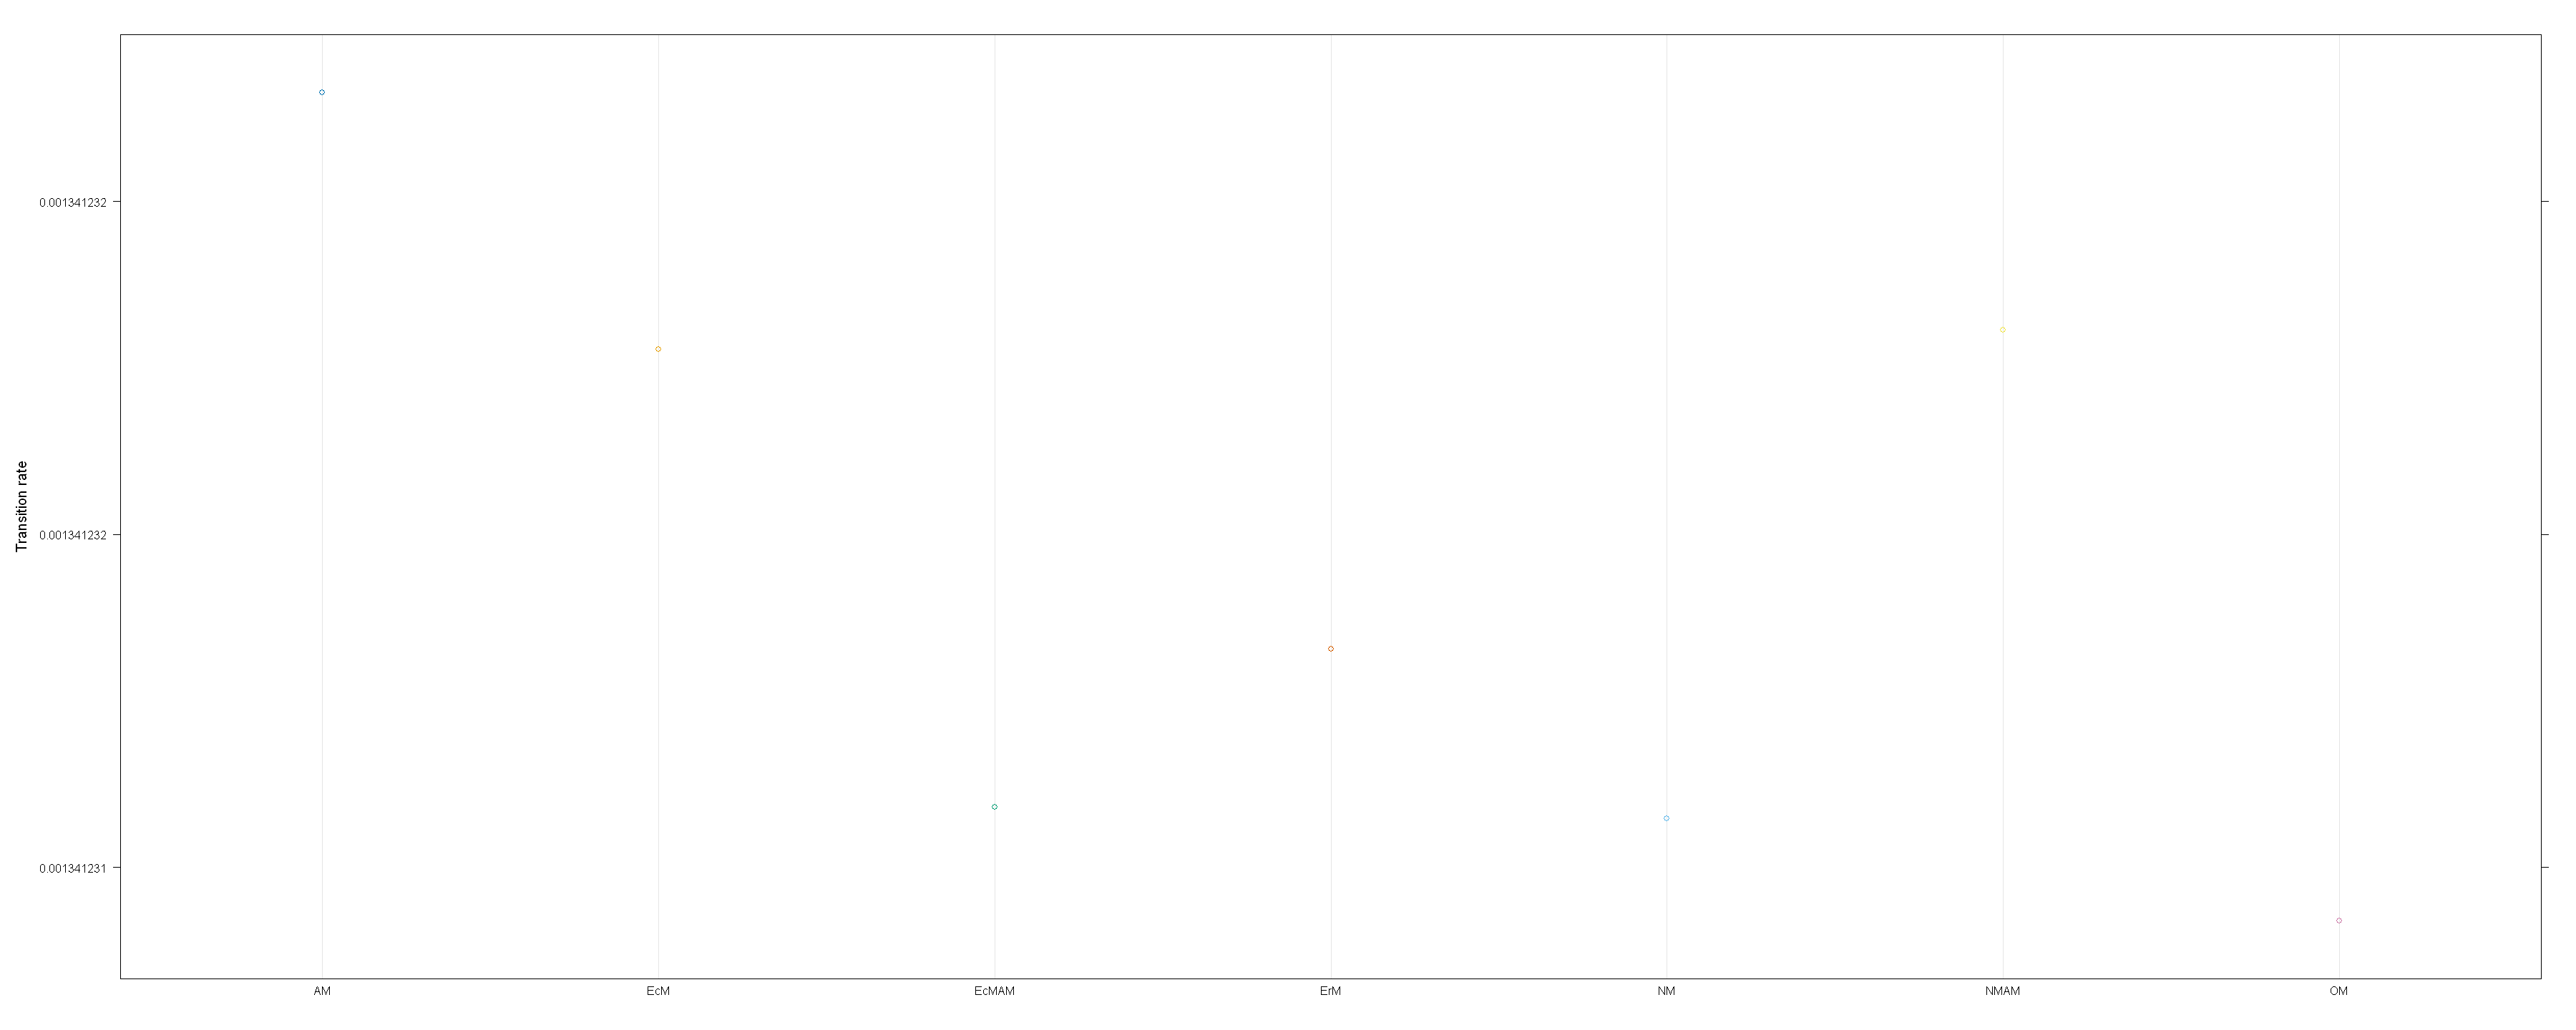

In [28]:
par(mfrow = c(2, 2)) # plots fill rows first i.e. (0, 0), (0, 1), (1, 0), (1, 1)
lattice::dotplot(rates~tip_state, data = avg_models_CD_RD_1005sp, group = tip_state, ylab = "Transition rate", )

Using tip_state as id variables



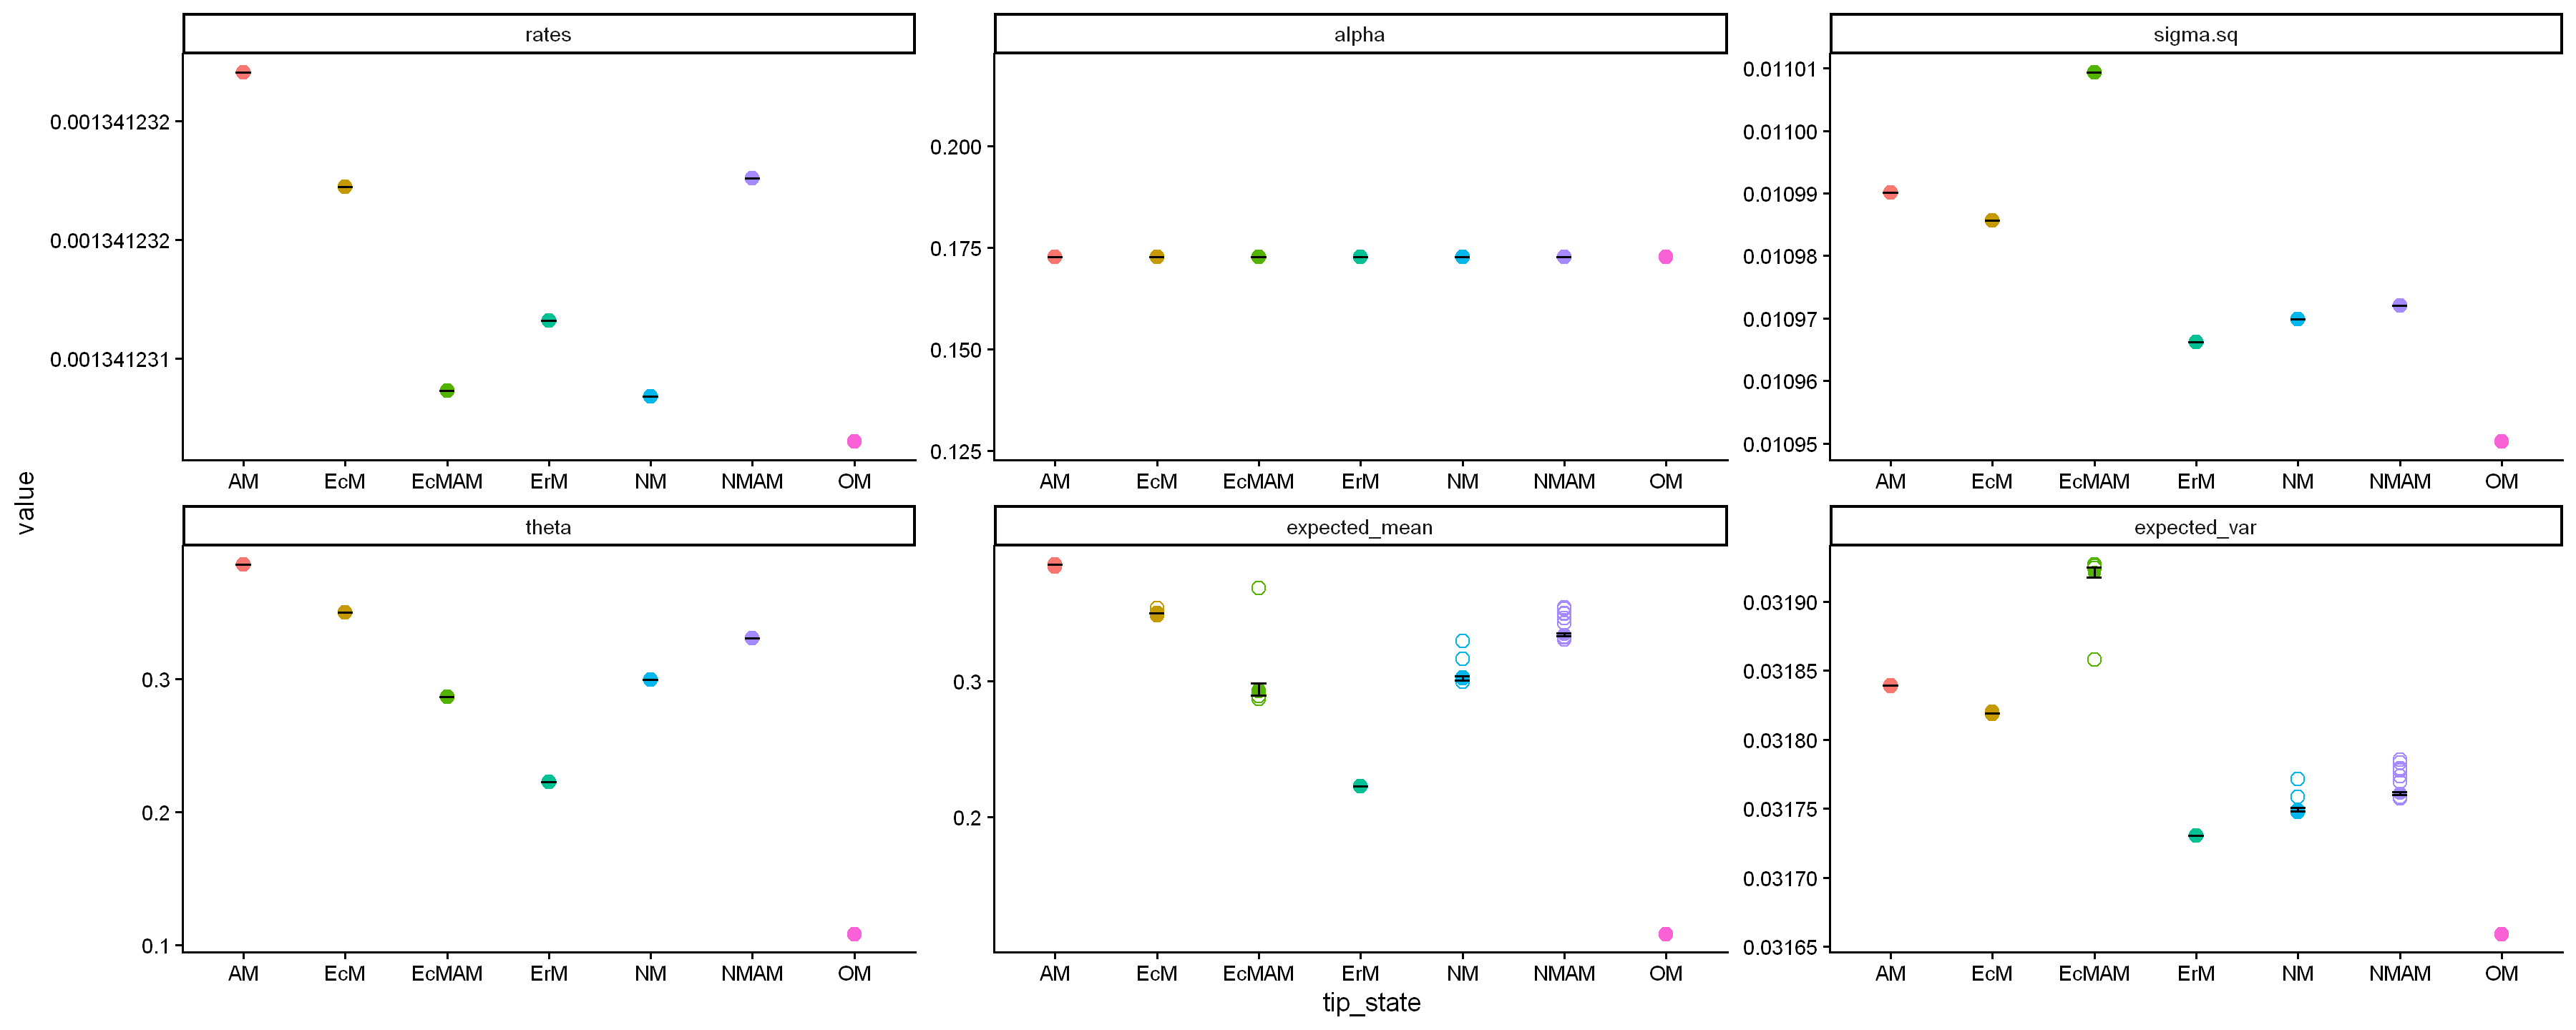

In [10]:
plot_df <- reshape2::melt(avg_models_CD_RD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



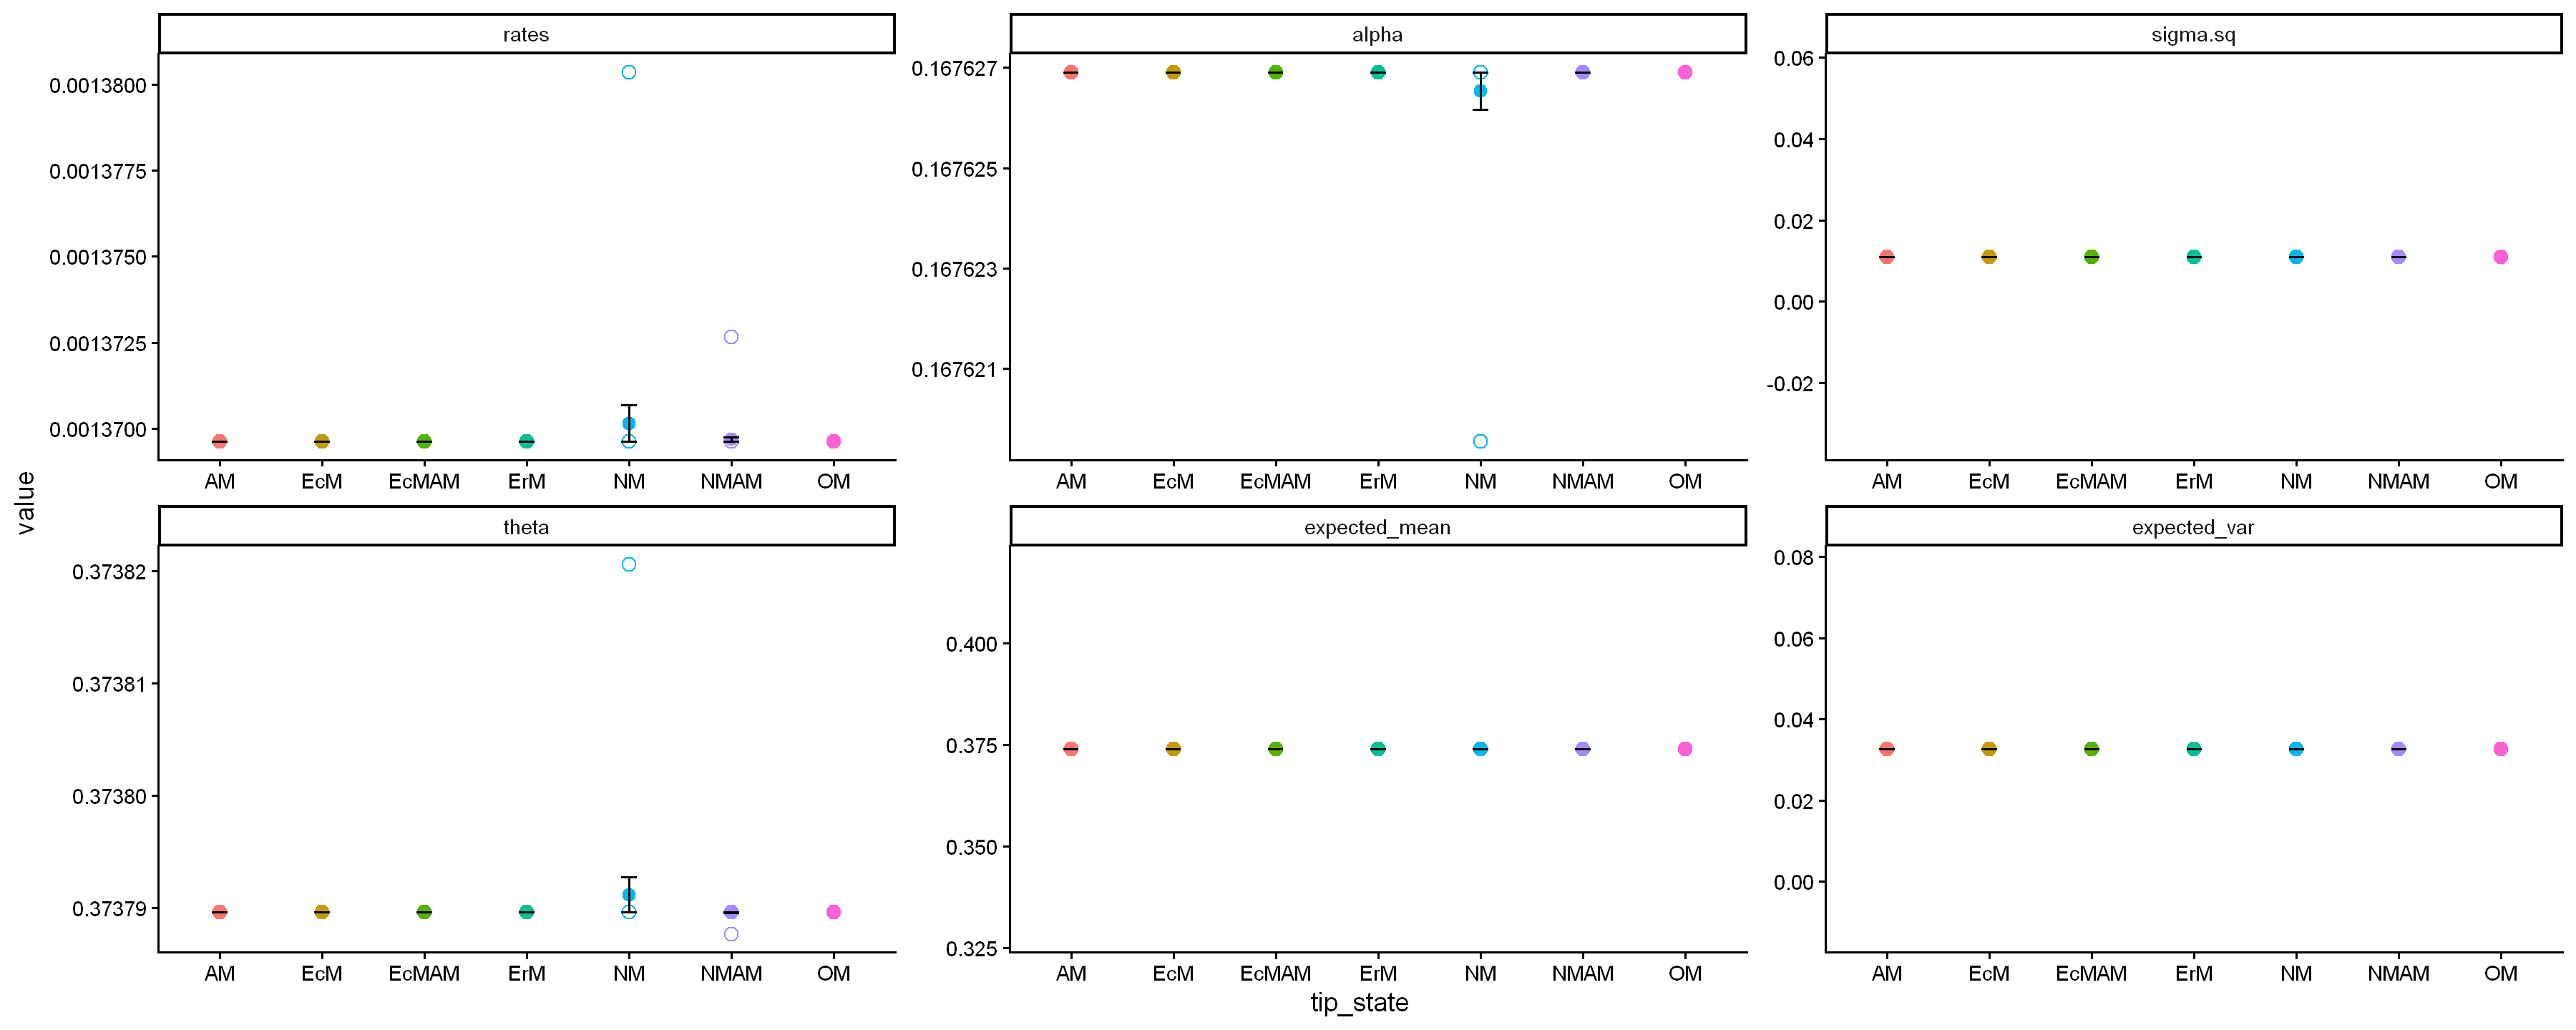

In [26]:
plot_df <- reshape2::melt(avg_models_CID_RD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [20]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 7 MYCORRHIZAL STATES
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_RD_1005sp <- readallRds(dirpath = "../rdata/parallel/LOG_RD_1005SP/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_RD_1005sp <- readallRds(dirpath = "../rdata/parallel/LOG_RD_1005SP/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logRD_1005sp <- OUwie::getModelAvgParams(models_CD_log_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logRD_1005sp <- OUwie::getModelAvgParams(models_CID_log_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_RD_1005sp, type = "AICc")
OUwie::getModelTable(models_CID_log_RD_1005sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,51,-891.9506,-263.0658,-626.0009,1891.467,1.286943,3.444622e-01
ARDOUMA,57,-1261.3591,-254.5180,-1002.0219,2643.700,753.520418,1.554956e-164
ARDOUMV,57,-1015.2664,-253.9821,-757.8765,2151.515,261.335047,1.170613e-57
ARDOUMVA,63,-1261.2951,-262.3275,-997.1680,2657.160,766.979890,1.857936e-167
EROUM,10,-1345.1618,-262.3762,-1078.4157,2710.545,820.365049,4.748876e-179
EROUMA,16,-1298.6951,-262.3421,-1033.0176,2629.941,739.761013,1.511941e-161
EROUMV,16,-928.8146,-262.3076,-663.0691,1890.180,0.000000,6.555378e-01
EROUMVA,22,-1261.0066,-262.3808,-997.5747,2567.044,676.863858,6.878259e-148
SYMOUM,30,-1322.6131,-240.4094,-1078.0701,2707.136,816.956012,2.611283e-178


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,90,-1.106001e+03,-291.0183,-820.5732,2.409923e+03,293601091,0
ARDOUMA,91,-1.358243e+03,-274.2612,-1088.9385,2.916826e+03,293601598,0
ARDOUMV,91,-9.695400e+02,-298.6706,-695.0465,2.139420e+03,293600821,0
ARDOUMVA,92,-1.340364e+03,-296.2951,-1051.9327,2.883491e+03,293601565,0
EROUM,8,-9.040159e+02,-262.3745,-638.3976,1.824176e+03,293600505,0
EROUMA,9,1.467993e+08,-262.9196,-973.3014,-2.935987e+08,0,1
EROUMV,9,-9.040199e+02,-262.3060,-638.3414,1.826221e+03,293600507,0
EROUMVA,10,-1.342213e+03,-262.2978,-1076.5537,2.704647e+03,293601386,0
SYMOUM,48,-9.361223e+02,-293.8078,-1384.6181,1.973165e+03,293600654,0


Using tip_state as id variables



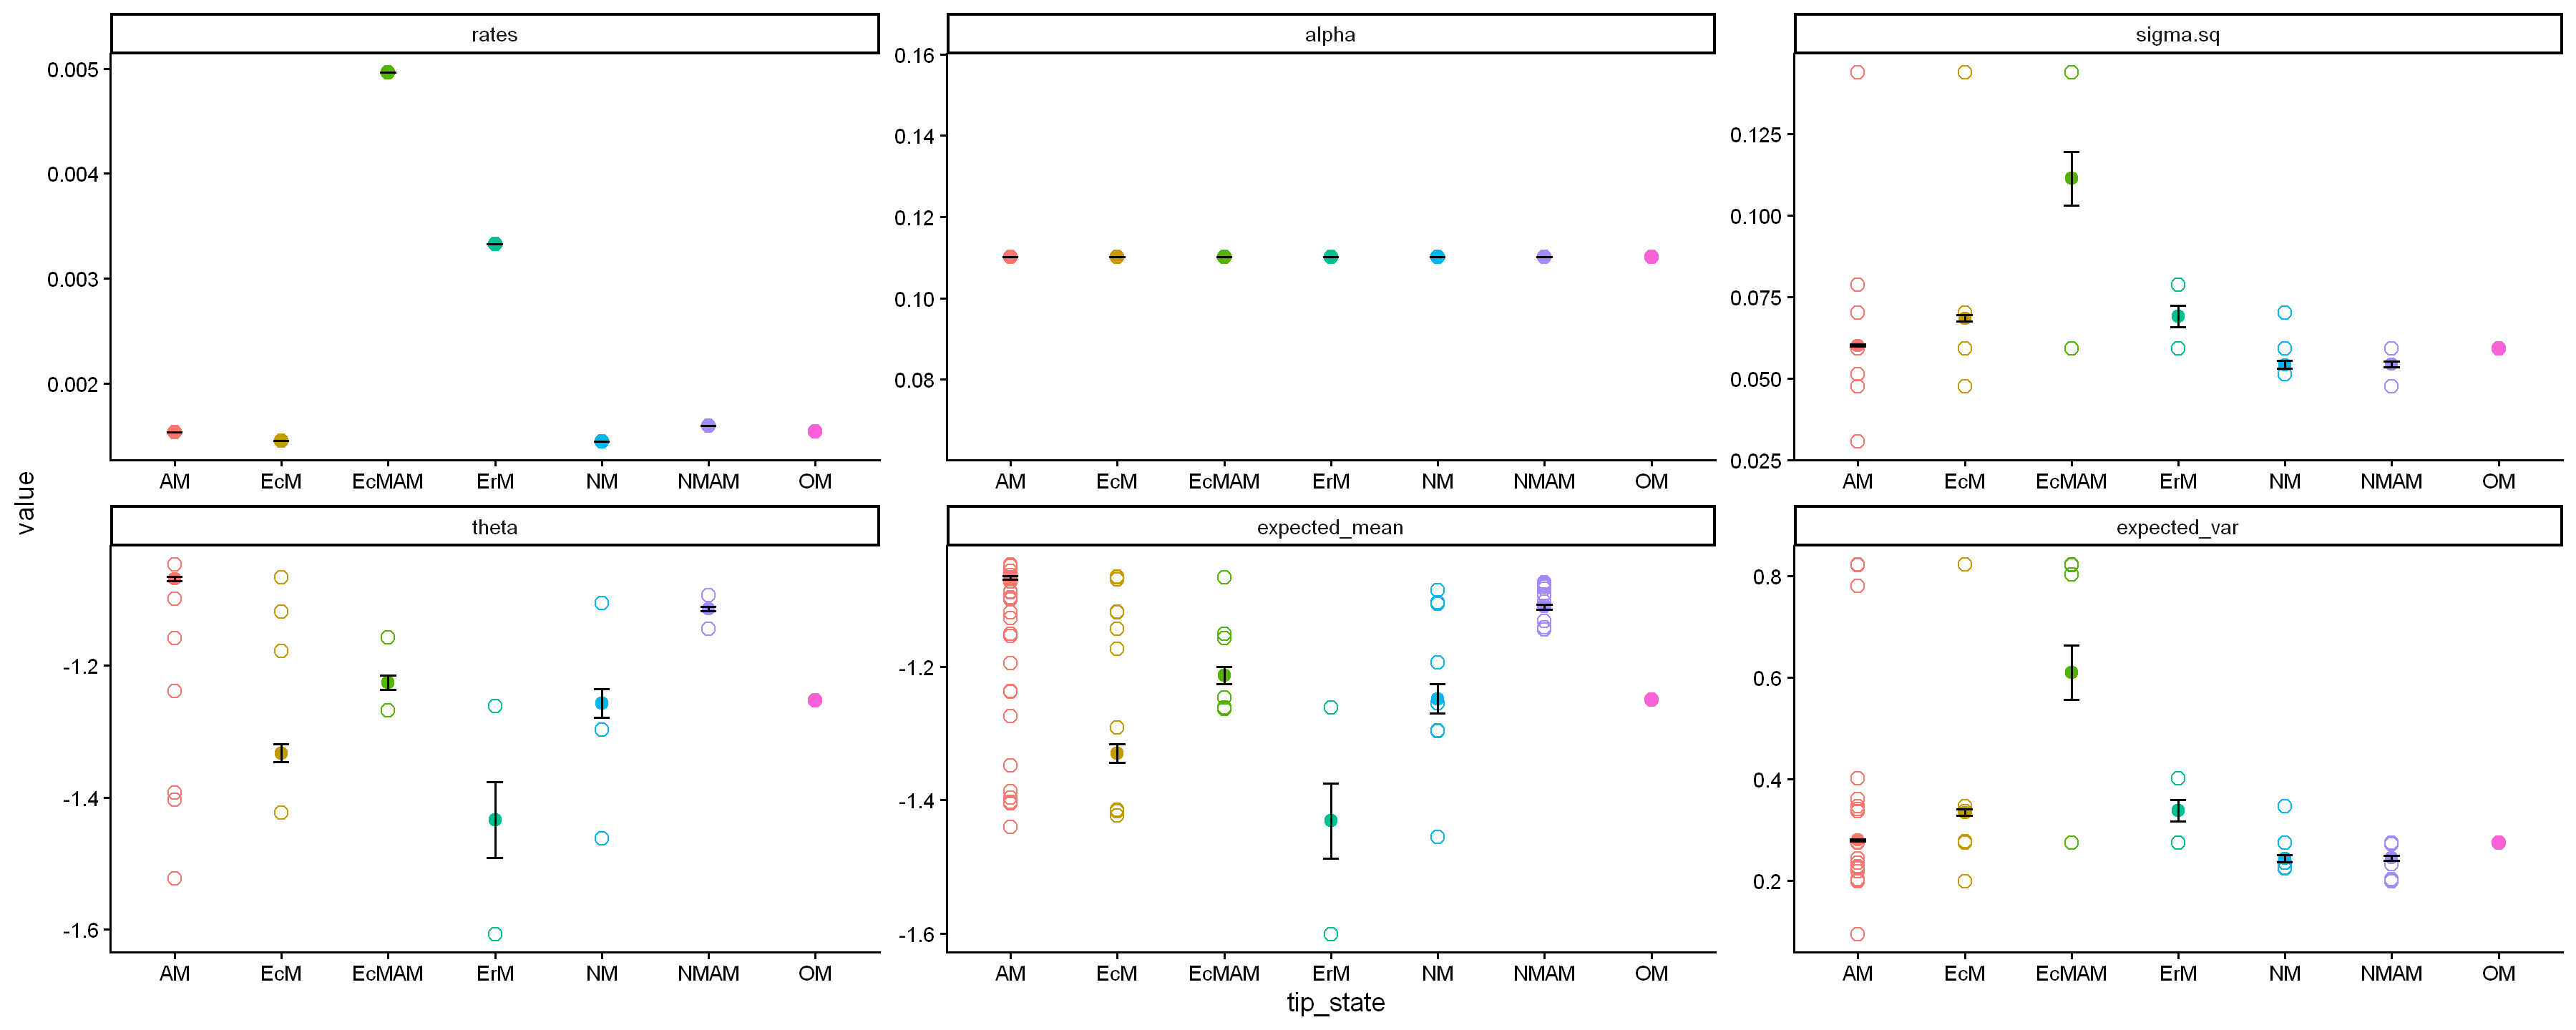

In [21]:
plot_df <- reshape2::melt(avg_models_CD_logRD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



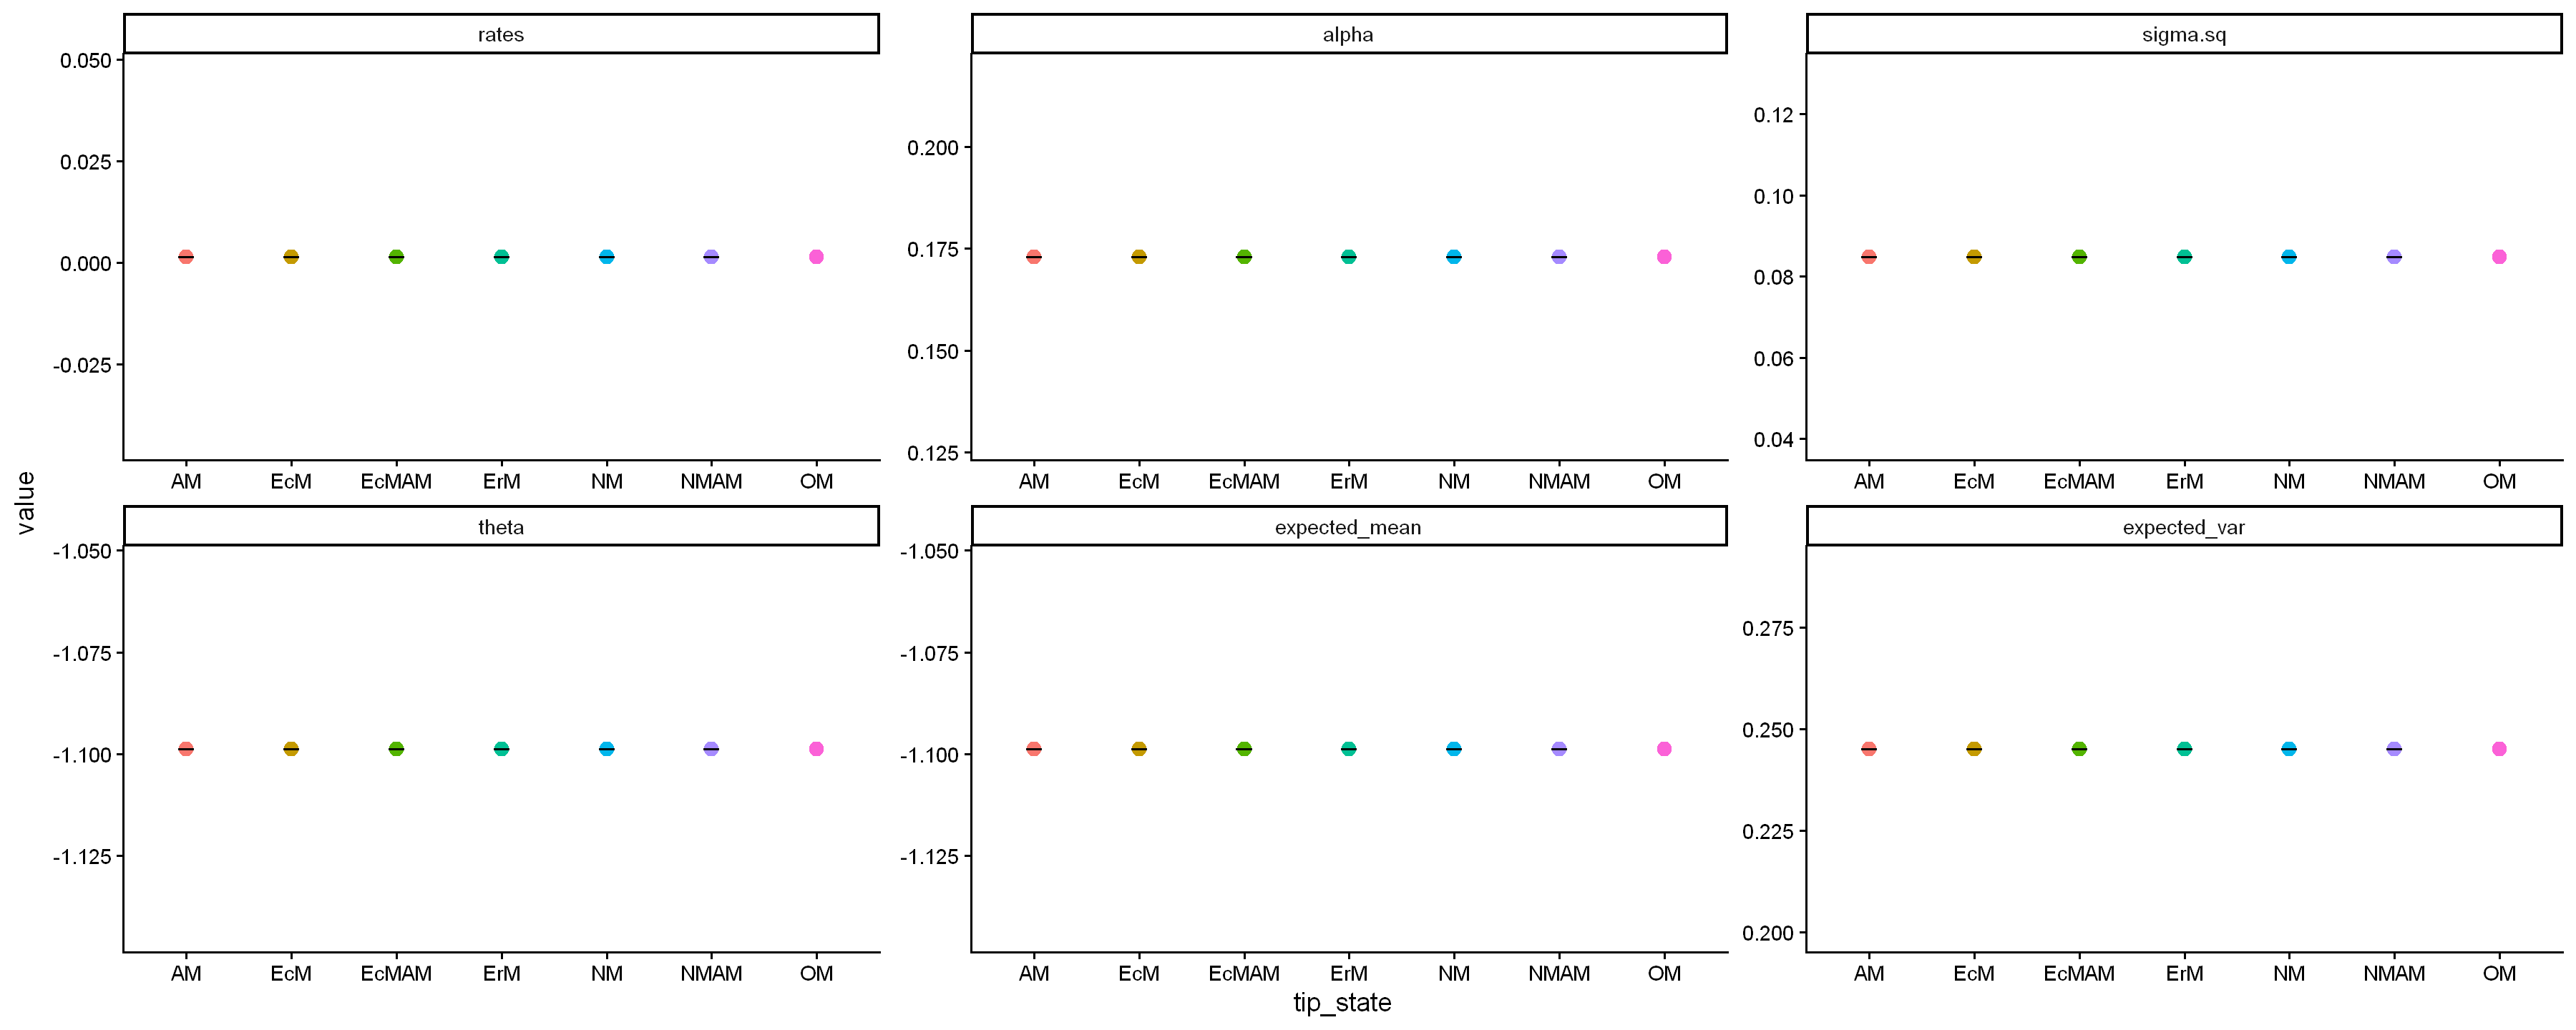

In [22]:
plot_df <- reshape2::melt(avg_models_CID_logRD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [16]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 4 MYCORRHIZAL STATES (ErM and OM removed & NM and AM/NM combined)
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_RD_994sp <- readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_4/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_RD_994sp <- readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_4/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logRD_994sp <- OUwie::getModelAvgParams(models_CD_log_RD_994sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logRD_994sp <- OUwie::getModelAvgParams(models_CID_log_RD_994sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_RD_994sp, type = "AICc")
OUwie::getModelTable(models_CID_log_RD_994sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,18,-736.9326,-120.5243,-613.1233,1510.567,21.15293,2.548736e-05
ARDOUMA,21,-1170.1164,-123.5417,-1059.0146,2383.184,893.76969,8.317682e-195
ARDOUMV,21,-782.5346,-120.7175,-658.4130,1608.020,118.60597,1.756572e-26
ARDOUMVA,24,-1125.9799,-133.8201,-992.2036,2301.198,811.78443,5.282941e-177
EROUM,7,-1189.8769,-124.3315,-1062.1632,2393.867,904.45352,3.981412e-197
EROUMA,10,-1064.1961,-124.3357,-937.9492,2148.616,659.20220,7.172744e-144
EROUMV,10,-734.5950,-124.3578,-608.3801,1489.414,0.00000,9.991356e-01
EROUMVA,13,-1039.0990,-124.3511,-913.2259,2104.569,615.15567,2.631897e-134
SYMOUM,12,-739.6305,-123.0639,-611.4325,1503.579,14.16516,8.388803e-04


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,30,-1165.9300,-155.7322,-1032.4249,2393.791,8376970,0
ARDOUMA,31,-1251.6592,-152.3569,-1145.8367,2567.381,8377143,0
ARDOUMV,31,-1163.3757,-153.5205,-1035.5155,2390.814,8376967,0
ARDOUMVA,32,-1199.9199,-158.2340,-1093.1383,2466.038,8377042,0
EROUM,8,-746.3854,-124.3916,-618.8126,1508.917,8376085,0
EROUMA,9,-1190.0606,-124.3930,-1062.6800,2398.304,8376974,0
EROUMV,9,-746.4018,-124.3376,-618.7032,1510.987,8376087,0
EROUMVA,10,4187298.1620,-124.8110,-772.0863,-8374576.100,0,1
SYMOUM,18,-745.1571,-123.1382,-619.4039,1527.016,8376103,0


Using tip_state as id variables



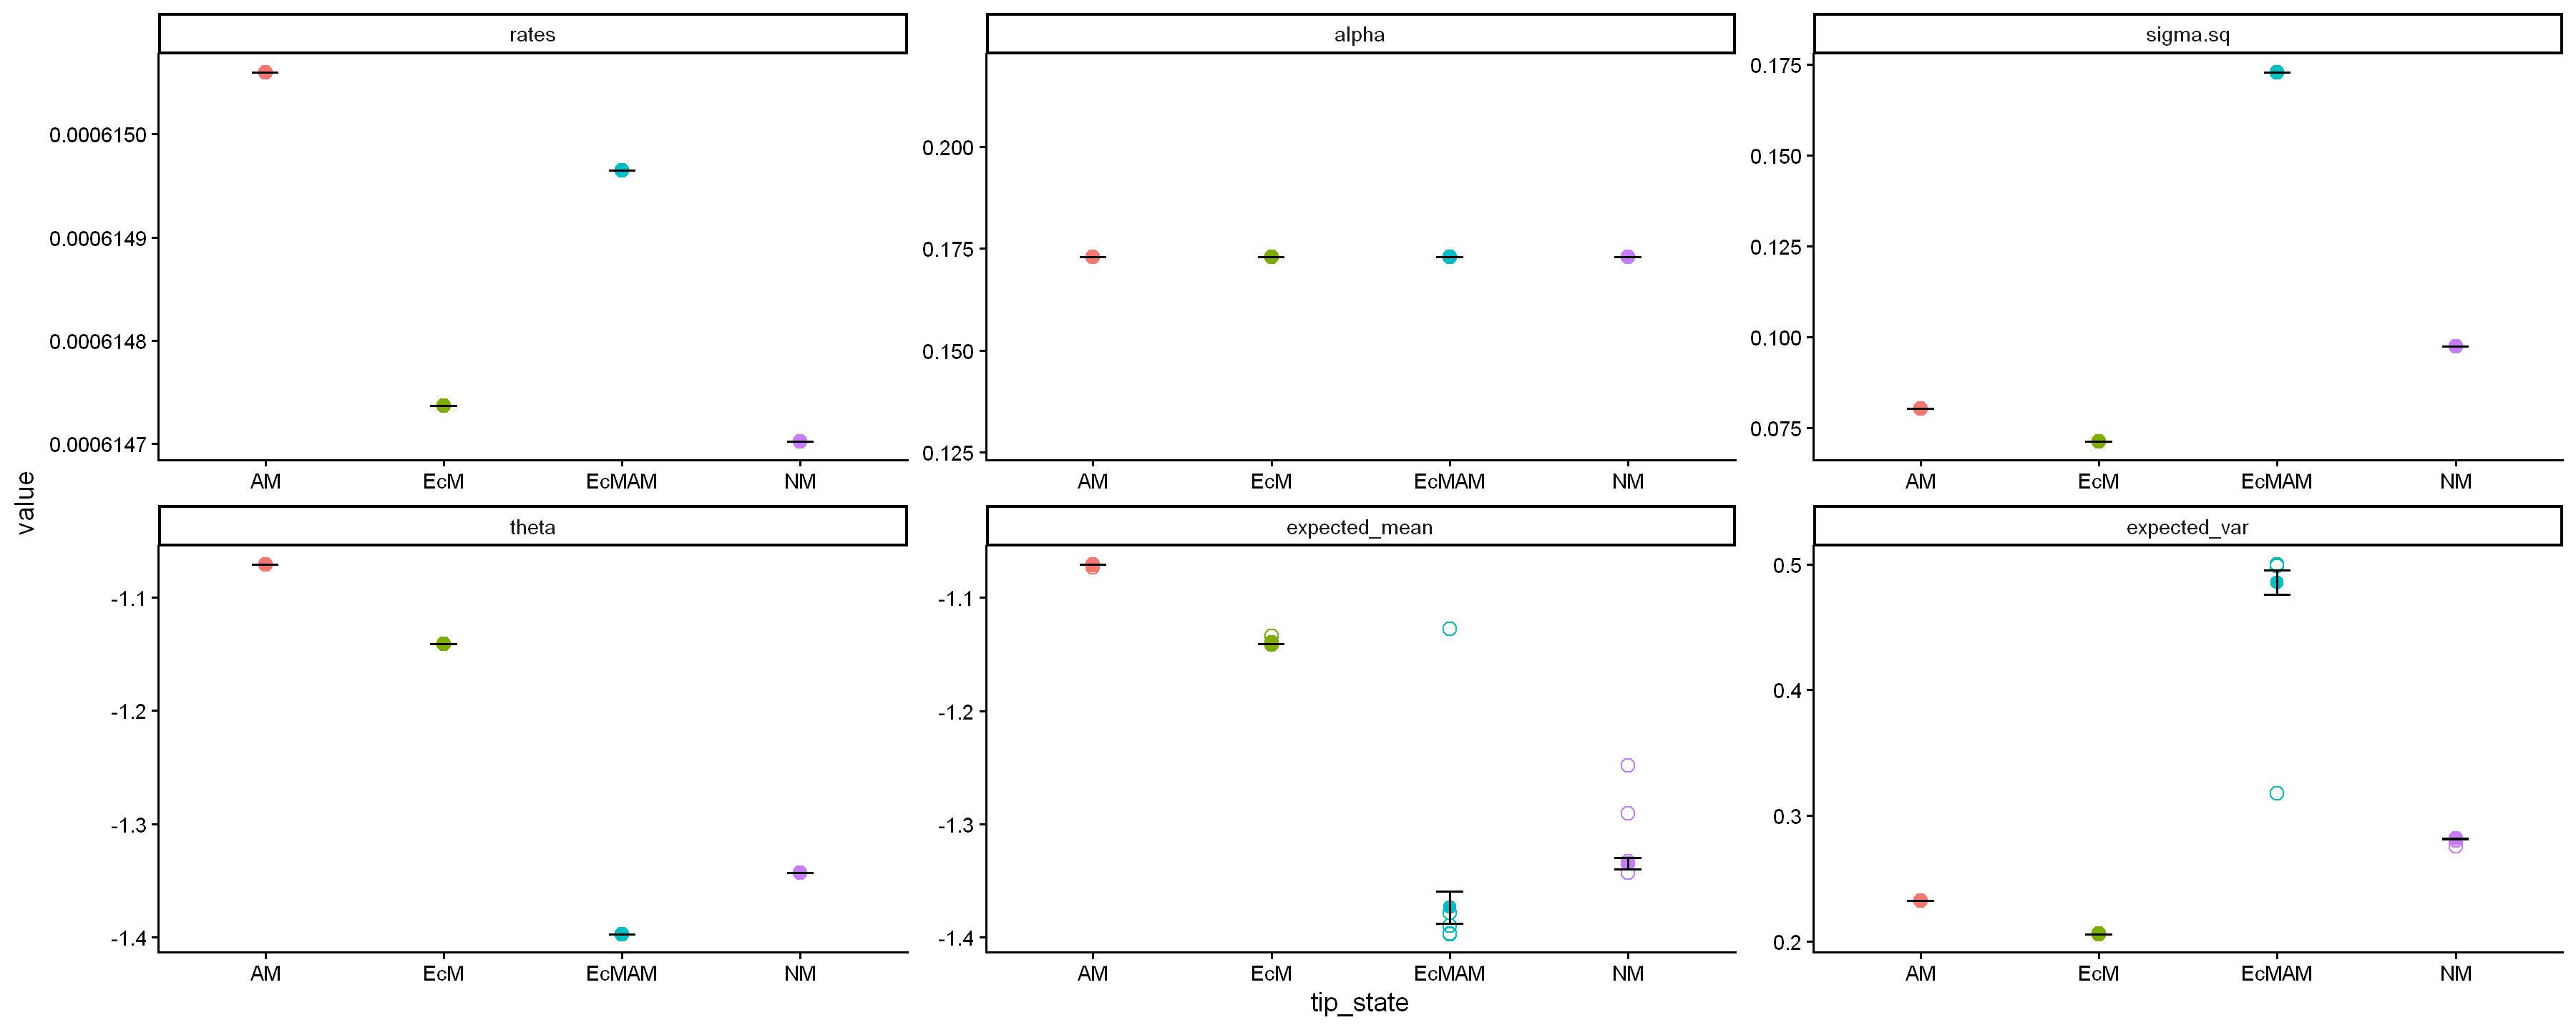

In [17]:
plot_df <- reshape2::melt(avg_models_CD_logRD_994sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



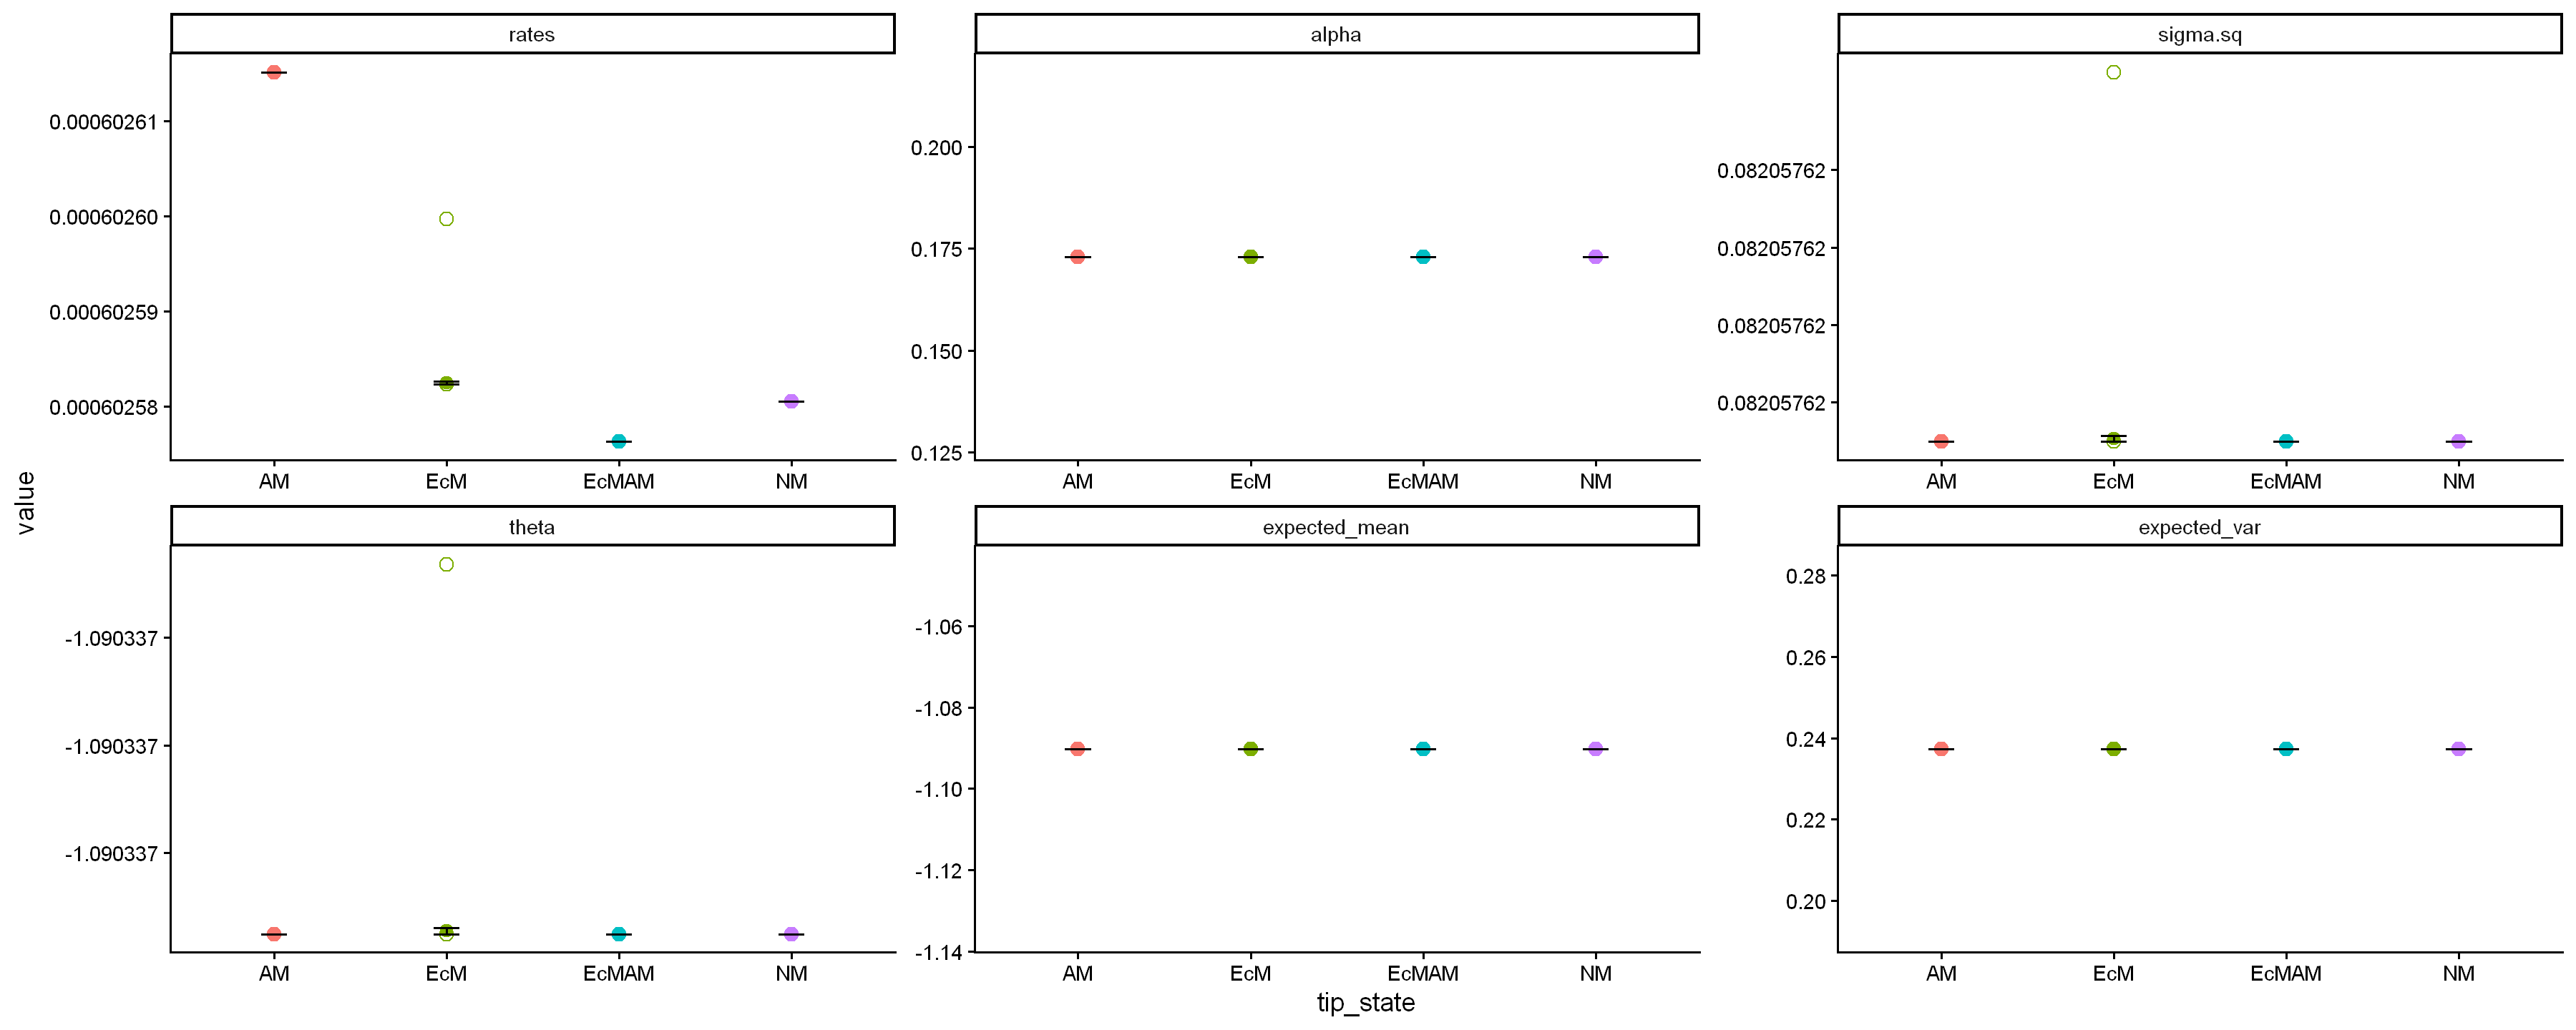

In [18]:
plot_df <- reshape2::melt(avg_models_CID_logRD_994sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [6]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 5 MYCORRHIZAL STATES (ErM and OM removed)
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_RD_994sp_5 <- readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_RD_994sp_5 <- readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logRD_994sp_5 <- OUwie::getModelAvgParams(models_CD_log_RD_994sp_5, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logRD_994sp_5 <- OUwie::getModelAvgParams(models_CID_log_RD_994sp_5, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_RD_994sp_5, type = "AICc")
OUwie::getModelTable(models_CID_log_RD_994sp_5, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-838.0351,-223.1565,-611.7567,1731.636,14.80085,6.096044e-04
ARDOUMA,31,-1238.2117,-224.5147,-1010.6562,2540.486,823.65112,1.397789e-179
ARDOUMV,31,-873.7338,-222.7896,-647.6073,1811.530,94.69539,2.730041e-21
ARDOUMVA,35,-1212.4339,-223.6016,-1000.8090,2497.498,780.66367,3.020291e-170
EROUM,8,-1304.1461,-236.0868,-1063.7740,2624.438,907.60367,8.229576e-198
EROUMA,12,-1249.3831,-235.9936,-1010.2334,2523.084,806.24948,8.397725e-176
EROUMV,12,-1237.9762,-235.9209,-998.5078,2500.270,783.43575,7.552639e-171
EROUMVA,16,-1226.9949,-236.6841,-987.3931,2486.547,769.71196,7.214091e-168
SYMOUM,17,-841.1038,-226.0549,-611.7098,1716.835,0.00000,9.977248e-01


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-1291.6169,-273.4410,-1034.4833,2679.800,947.622675,9.913387e-207
ARDOUMA,47,-1330.6948,-263.3446,-1113.5676,2760.159,1027.982135,3.518738e-224
ARDOUMV,47,-1203.0682,-264.1869,-988.2174,2504.906,772.728939,9.417034e-169
ARDOUMVA,48,-1322.7397,-263.3626,-1106.3970,2746.457,1014.280183,3.324512e-221
EROUM,8,-858.0154,-236.0211,-618.7303,1732.177,0.000000,5.886692e-01
EROUMA,9,-858.0134,-235.9673,-618.7297,1734.210,2.032610,2.130569e-01
EROUMV,9,-858.0853,-236.0851,-618.6601,1734.354,2.176431,1.982738e-01
EROUMVA,10,-1301.0655,-236.0230,-1062.3186,2622.355,890.177697,2.952844e-194
SYMOUM,26,-869.6505,-254.0729,-618.7855,1792.753,60.575857,4.130391e-14


Using tip_state as id variables



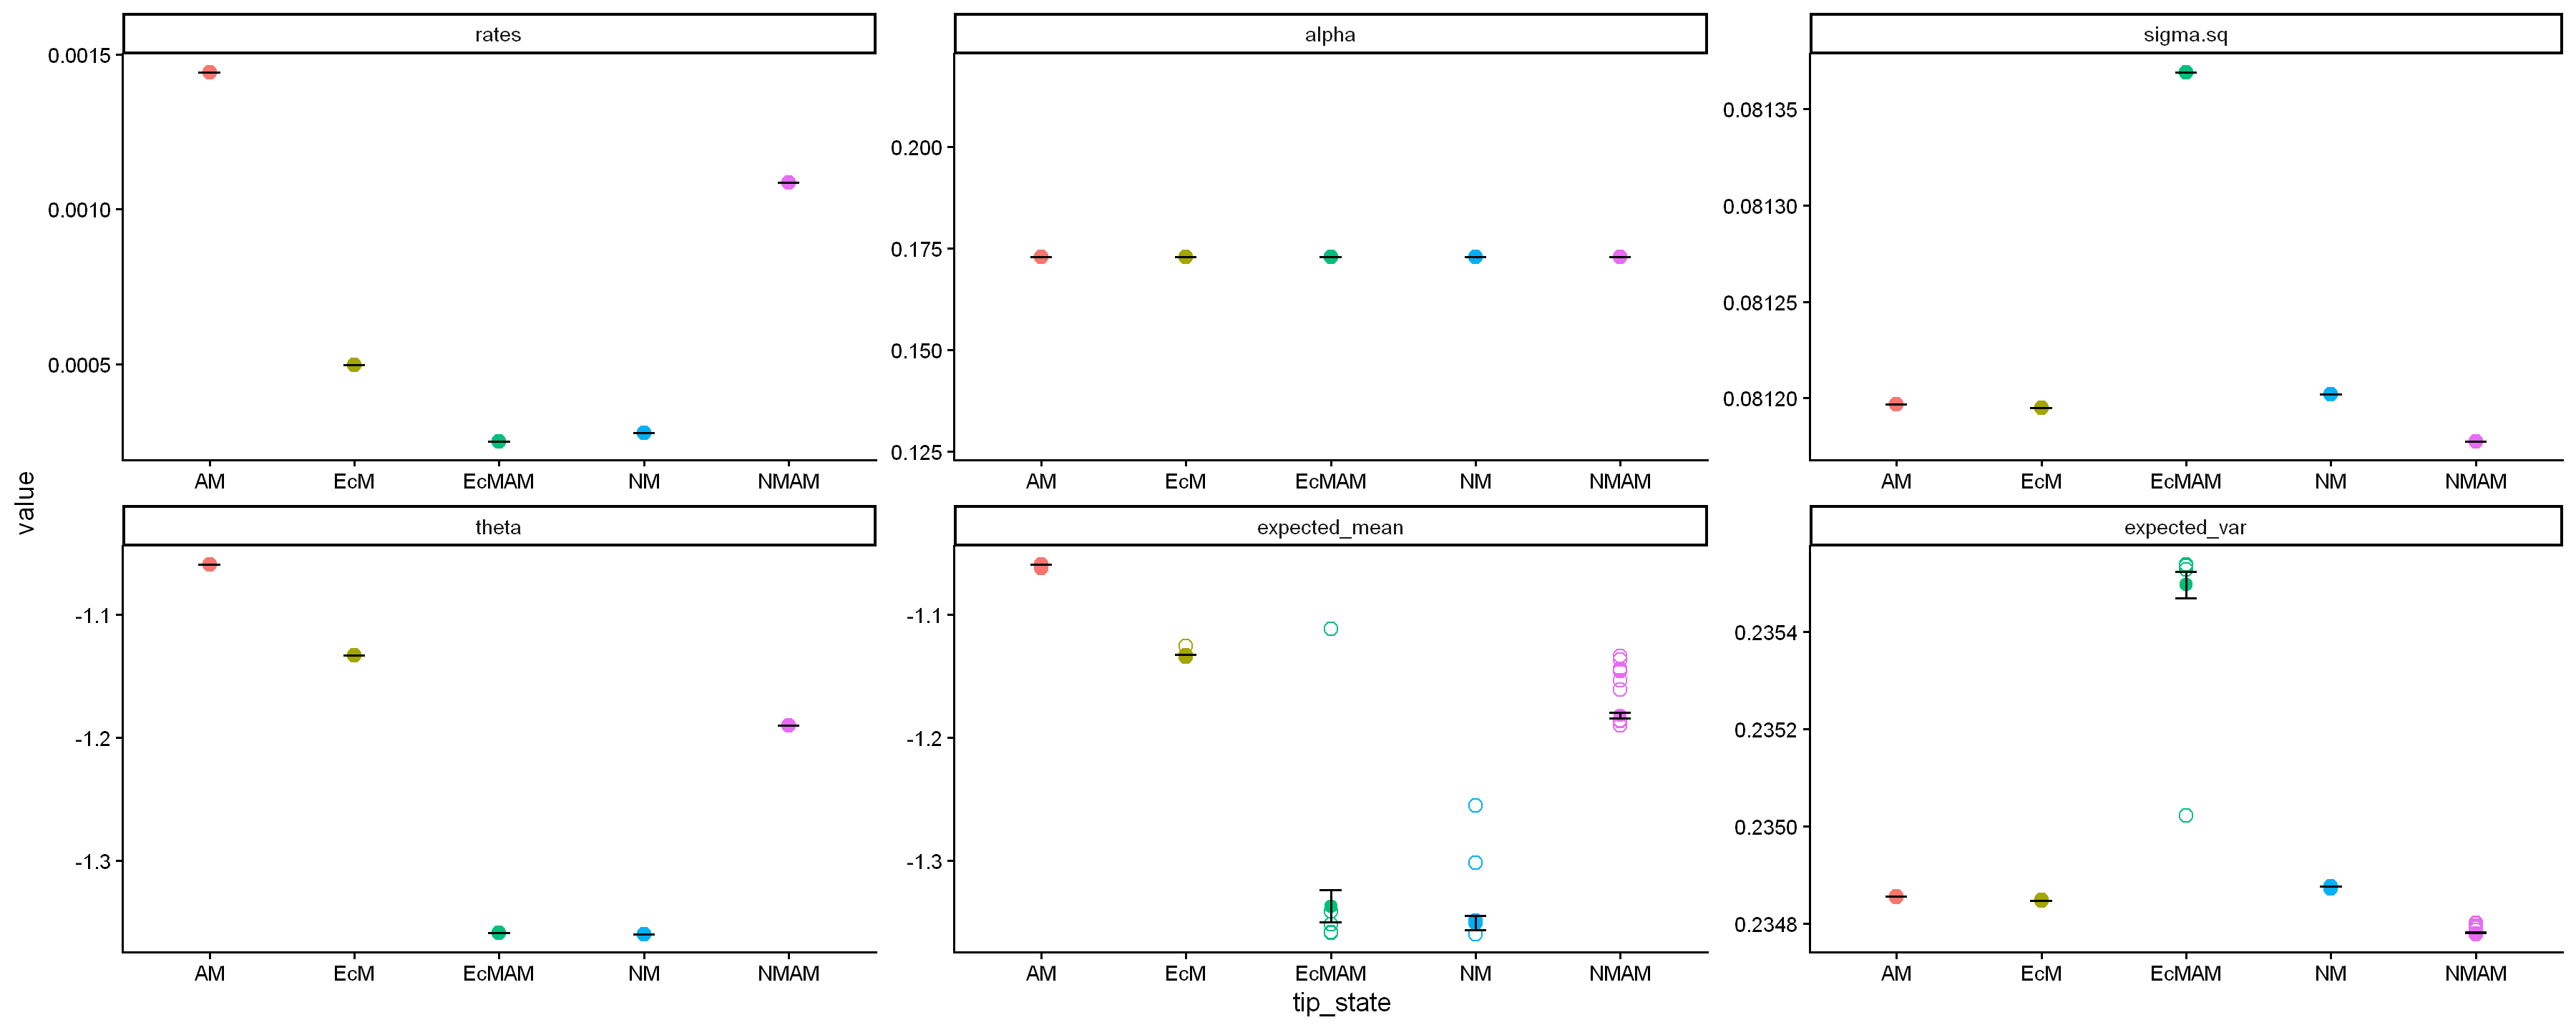

In [7]:
plot_df <- reshape2::melt(avg_models_CD_logRD_994sp_5)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



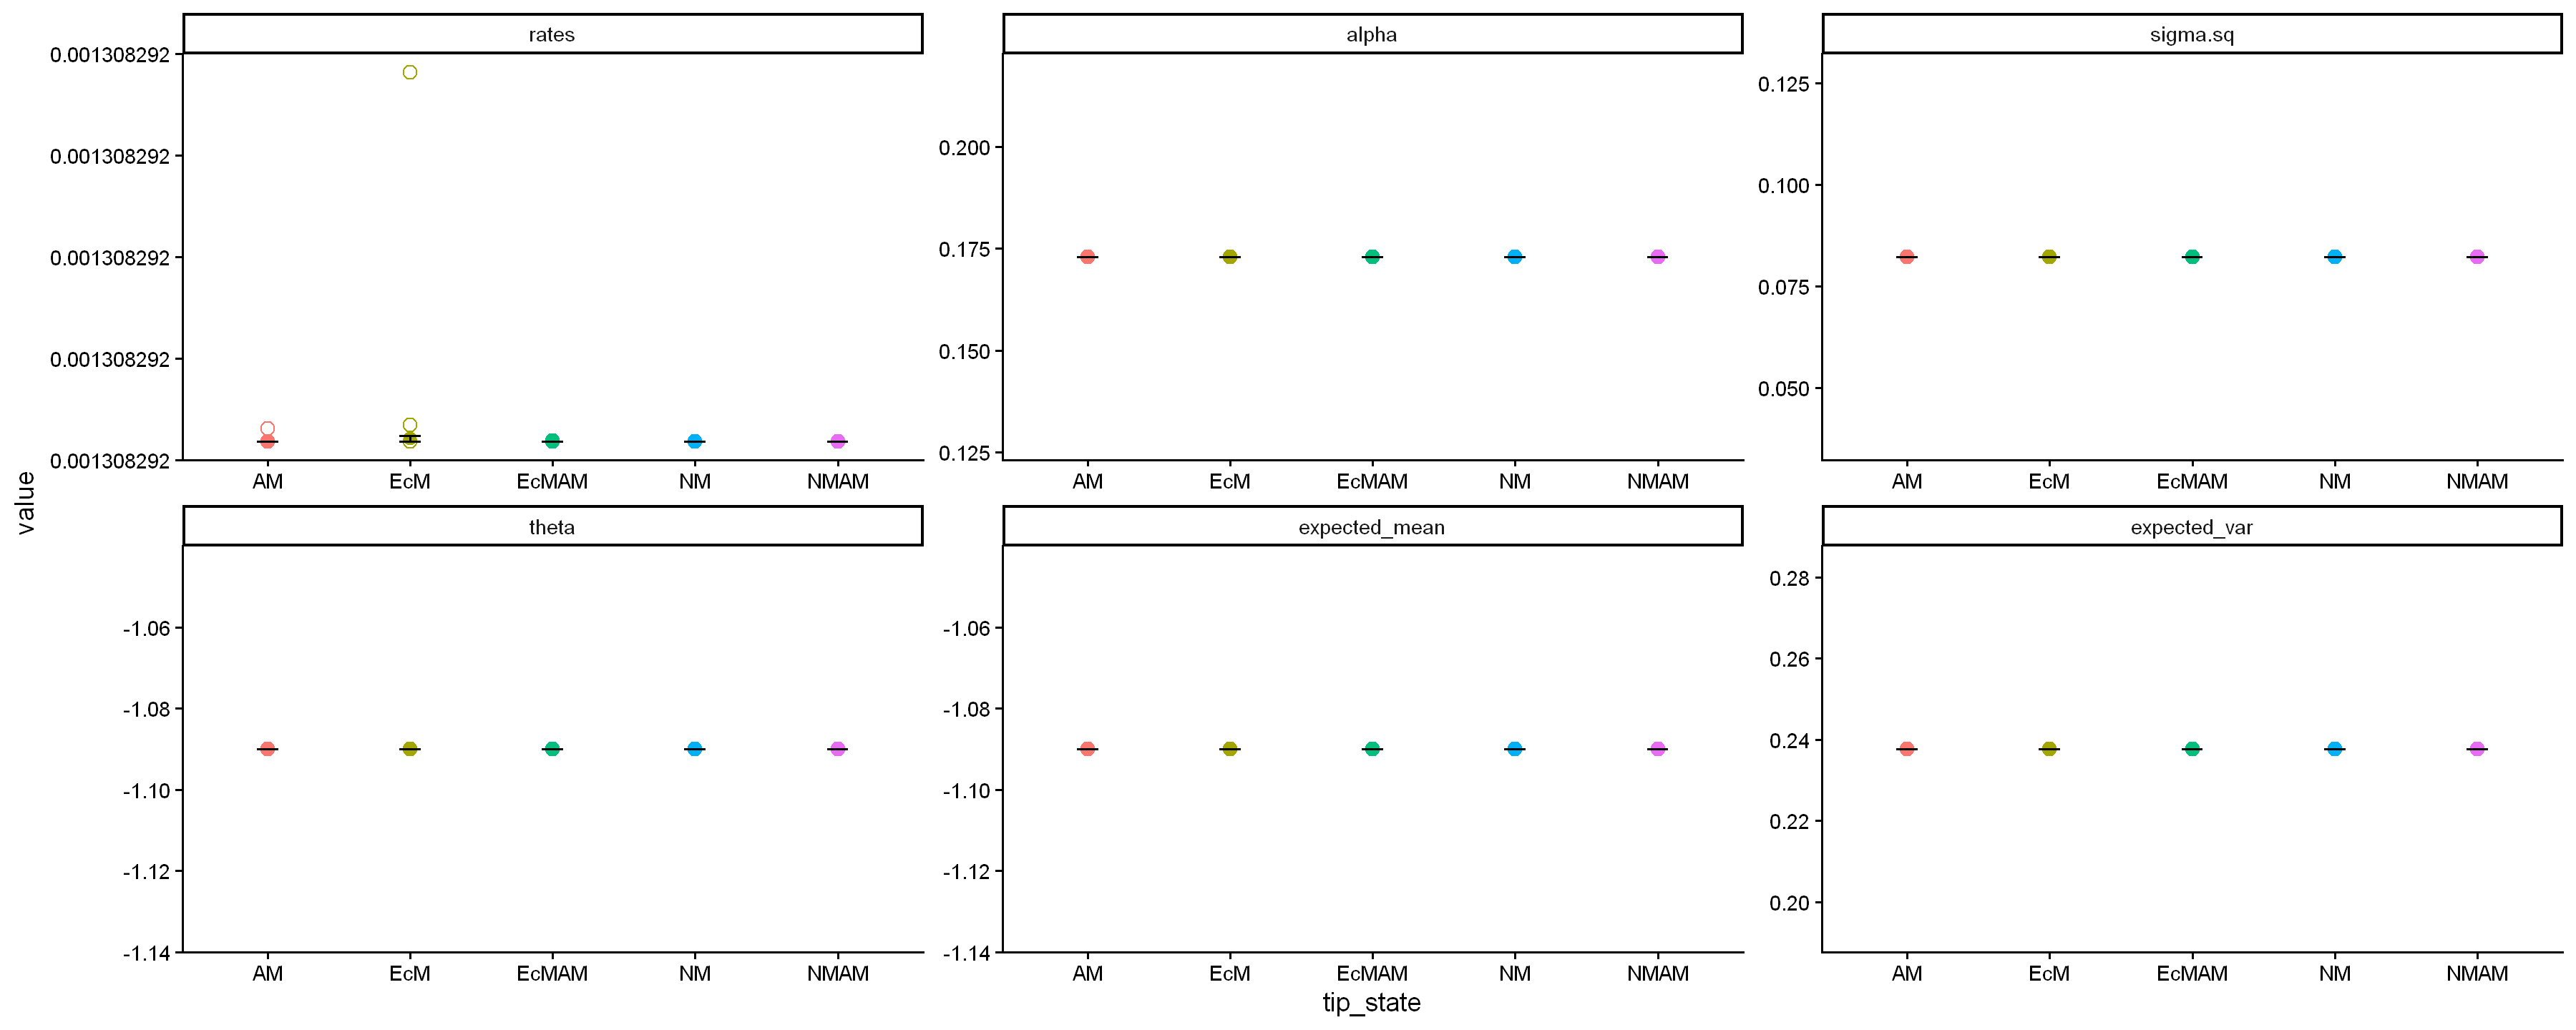

In [8]:
plot_df <- reshape2::melt(avg_models_CID_logRD_994sp_5)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

## ___Specific root length (SRL)___
------------------

In [ ]:
load("./rdata/OU_SRL_CD.RData")
load("./rdata/OU_SRL_CID.RData")

models_CD_SRL <- list(EROUM=ER_OUM_SRL_CD, EROUMA=ER_OUMA_SRL_CD, EROUMV=ER_OUMV_SRL_CD, EROUMVA=ER_OUMVA_SRL_CD, ARDOUM=ARD_OUM_SRL_CD,
                     ARDOUMA=ARD_OUMA_SRL_CD, ARDOUMV=ARD_OUMV_SRL_CD, ARDOUMVA=ARD_OUMVA_SRL_CD, SYMOUM=SYM_OUM_SRL_CD, SYMOUMA=SYM_OUMA_SRL_CD,
                     SYMOUMV=SYM_OUMV_SRL_CD, SYMOUMVA=SYM_OUMVA_SRL_CD)

models_CID_SRL <- list(EROUM=ER_OUM_SRL_CID, EROUMA=ER_OUMA_SRL_CID, EROUMV=ER_OUMV_SRL_CID, EROUMVA=ER_OUMVA_SRL_CID, ARDOUM=ARD_OUM_SRL_CID,
                        ARDOUMA=ARD_OUMA_SRL_CID, ARDOUMV=ARD_OUMV_SRL_CID, ARDOUMVA=ARD_OUMVA_SRL_CID, SYMOUM=SYM_OUM_SRL_CID, SYMOUMA=SYM_OUMA_SRL_CID,
                        SYM_OUMV=SYM_OUMV_SRL_CID, SYMOUMVA=SYM_OUMVA_SRL_CID)

avg_models_CD_SRL <- OUwie::getModelAvgParams(models_CD_SRL, type = "AICc", force = FALSE)
avg_models_CID_SRL <- OUwie::getModelAvgParams(models_CID_SRL, type = "AICc", force = FALSE)

OUwie::getModelTable(models_CD_SRL, type = "AICc")
OUwie::getModelTable(models_CID_SRL, type = "AICc")

In [ ]:
plot_df <- reshape2::melt(avg_models_CD_SRL)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")

In [ ]:
plot_df <- reshape2::melt(avg_models_CID_SRL)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")

In [ ]:
load("./rdata/OU_SRL_CID_4states.RData")
load("./rdata/OU_SRL_CD_4states.RData")


models_CD_SRL_4states <- list(EROUM=ER_OUM_SRL_CD, EROUMA=ER_OUMA_SRL_CD, EROUMV=ER_OUMV_SRL_CD, EROUMVA=ER_OUMVA_SRL_CD, ARDOUM=ARD_OUM_SRL_CD,
                              ARDOUMA=ARD_OUMA_SRL_CD, ARDOUMV=ARD_OUMV_SRL_CD, ARDOUMVA=ARD_OUMVA_SRL_CD, SYMOUM=SYM_OUM_SRL_CD, SYMOUMA=SYM_OUMA_SRL_CD,
                              SYMOUMV=SYM_OUMV_SRL_CD, SYMOUMVA=SYM_OUMVA_SRL_CD)

models_CID_SRL_4states <- list(EROUM=ER_OUM_SRL_CID, EROUMA=ER_OUMA_SRL_CID, EROUMV=ER_OUMV_SRL_CID, EROUMVA=ER_OUMVA_SRL_CID, ARDOUM=ARD_OUM_SRL_CID,
                               ARDOUMA=ARD_OUMA_SRL_CID, ARDOUMV=ARD_OUMV_SRL_CID, ARDOUMVA=ARD_OUMVA_SRL_CID, SYMOUM=SYM_OUM_SRL_CID, SYMOUMA=SYM_OUMA_SRL_CID,
                               SYM_OUMV=SYM_OUMV_SRL_CID, SYMOUMVA=SYM_OUMVA_SRL_CID)

avg_models_CD_SRL_4states <- OUwie::getModelAvgParams(models_CD_SRL_4states, type = "AICc", force = FALSE)
avg_models_CID_SRL_4states <- OUwie::getModelAvgParams(models_CID_SRL_4states, type = "AICc", force = FALSE)

In [ ]:
plot_df <- reshape2::melt(avg_models_CID_SRL_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")

In [ ]:
plot_df <- reshape2::melt(avg_models_CD_SRL_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    facet_wrap(~variable, scales = "free")

In [9]:
#------------------------------------------------------------------------------------------------------------------------------------
# SPECIFIC ROOT LENGTH (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 7 MYCORRHIZAL STATES
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_SRL_1005sp <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_1005SP/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_SRL_1005sp <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_1005SP/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logSRL_1005sp <- OUwie::getModelAvgParams(models_CD_log_SRL_1005sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logSRL_1005sp <- OUwie::getModelAvgParams(models_CID_log_SRL_1005sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_SRL_1005sp, type = "AICc")
OUwie::getModelTable(models_CID_log_SRL_1005sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,51,-898.1708,-260.3915,-634.7155,1903.907,0.0000,1.000000e+00
ARDOUMA,57,-1401.9390,-262.3093,-1148.3700,2924.860,1020.9529,2.008615e-222
ARDOUMV,57,-1008.4234,-261.9676,-743.0982,2137.829,233.9215,1.601722e-51
ARDOUMVA,63,-1313.4300,-262.4790,-1042.1171,2761.430,857.5224,6.185542e-187
EROUM,10,-1344.9437,-262.3738,-1078.6203,2710.109,806.2014,8.621633e-176
EROUMA,16,-1292.8861,-262.3264,-1025.8871,2618.323,714.4155,7.356033e-156
EROUMV,16,-1278.2132,-262.2948,-1012.8101,2588.977,685.0698,1.733776e-149
EROUMVA,22,-1262.7967,-262.3810,-1000.2233,2570.624,666.7167,1.676092e-145
SYMOUM,30,-1320.1642,-240.2483,-1076.5583,2702.238,798.3308,4.412287e-174


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,90,-1205.1595,-305.7209,-1055.4193,2608.2403,3076.962,0
ARDOUMA,91,-1372.6080,-290.6633,-1097.3725,2945.5555,3414.277,0
ARDOUMV,91,-1359.2967,-294.2482,-1055.3599,2918.9329,3387.654,0
ARDOUMVA,92,-1345.5195,-303.1490,-1104.3710,2893.8022,3362.524,0
EROUM,8,-904.0246,-262.3221,-638.3662,1824.1938,2292.915,0
EROUMA,9,243.4512,-263.4361,-678.7273,-468.7216,0.000,1
EROUMV,9,-937.2901,-262.3725,-671.5529,1892.7611,2361.483,0
EROUMVA,10,-908.9466,-262.4427,-643.2965,1838.1145,2306.836,0
SYMOUM,48,-915.8114,-284.8192,-637.0061,1932.5432,2401.265,0


Using tip_state as id variables



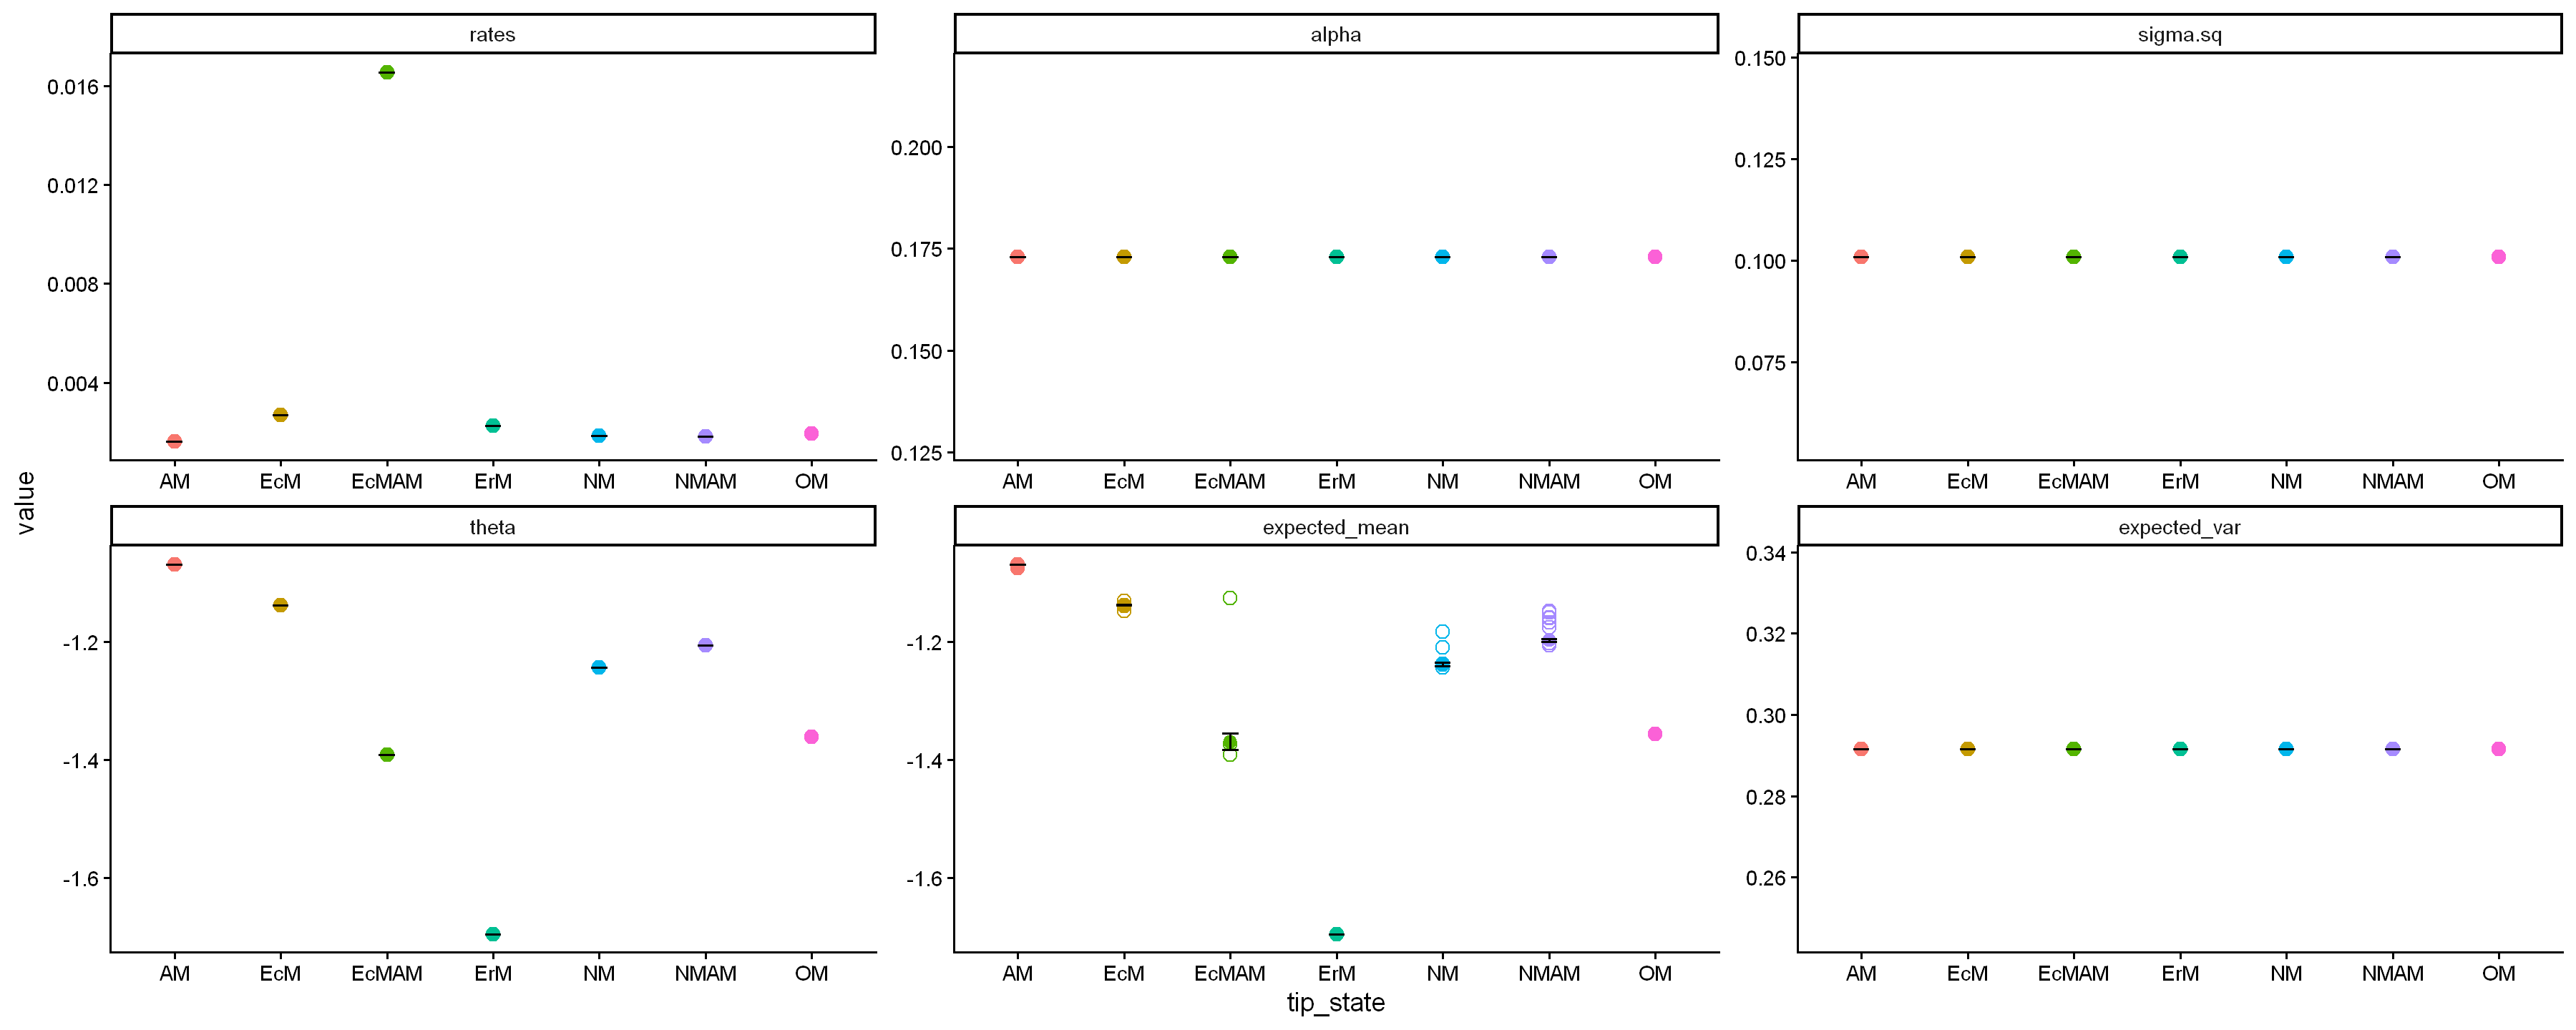

In [11]:
plot_df <- reshape2::melt(avg_models_CD_logSRL_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



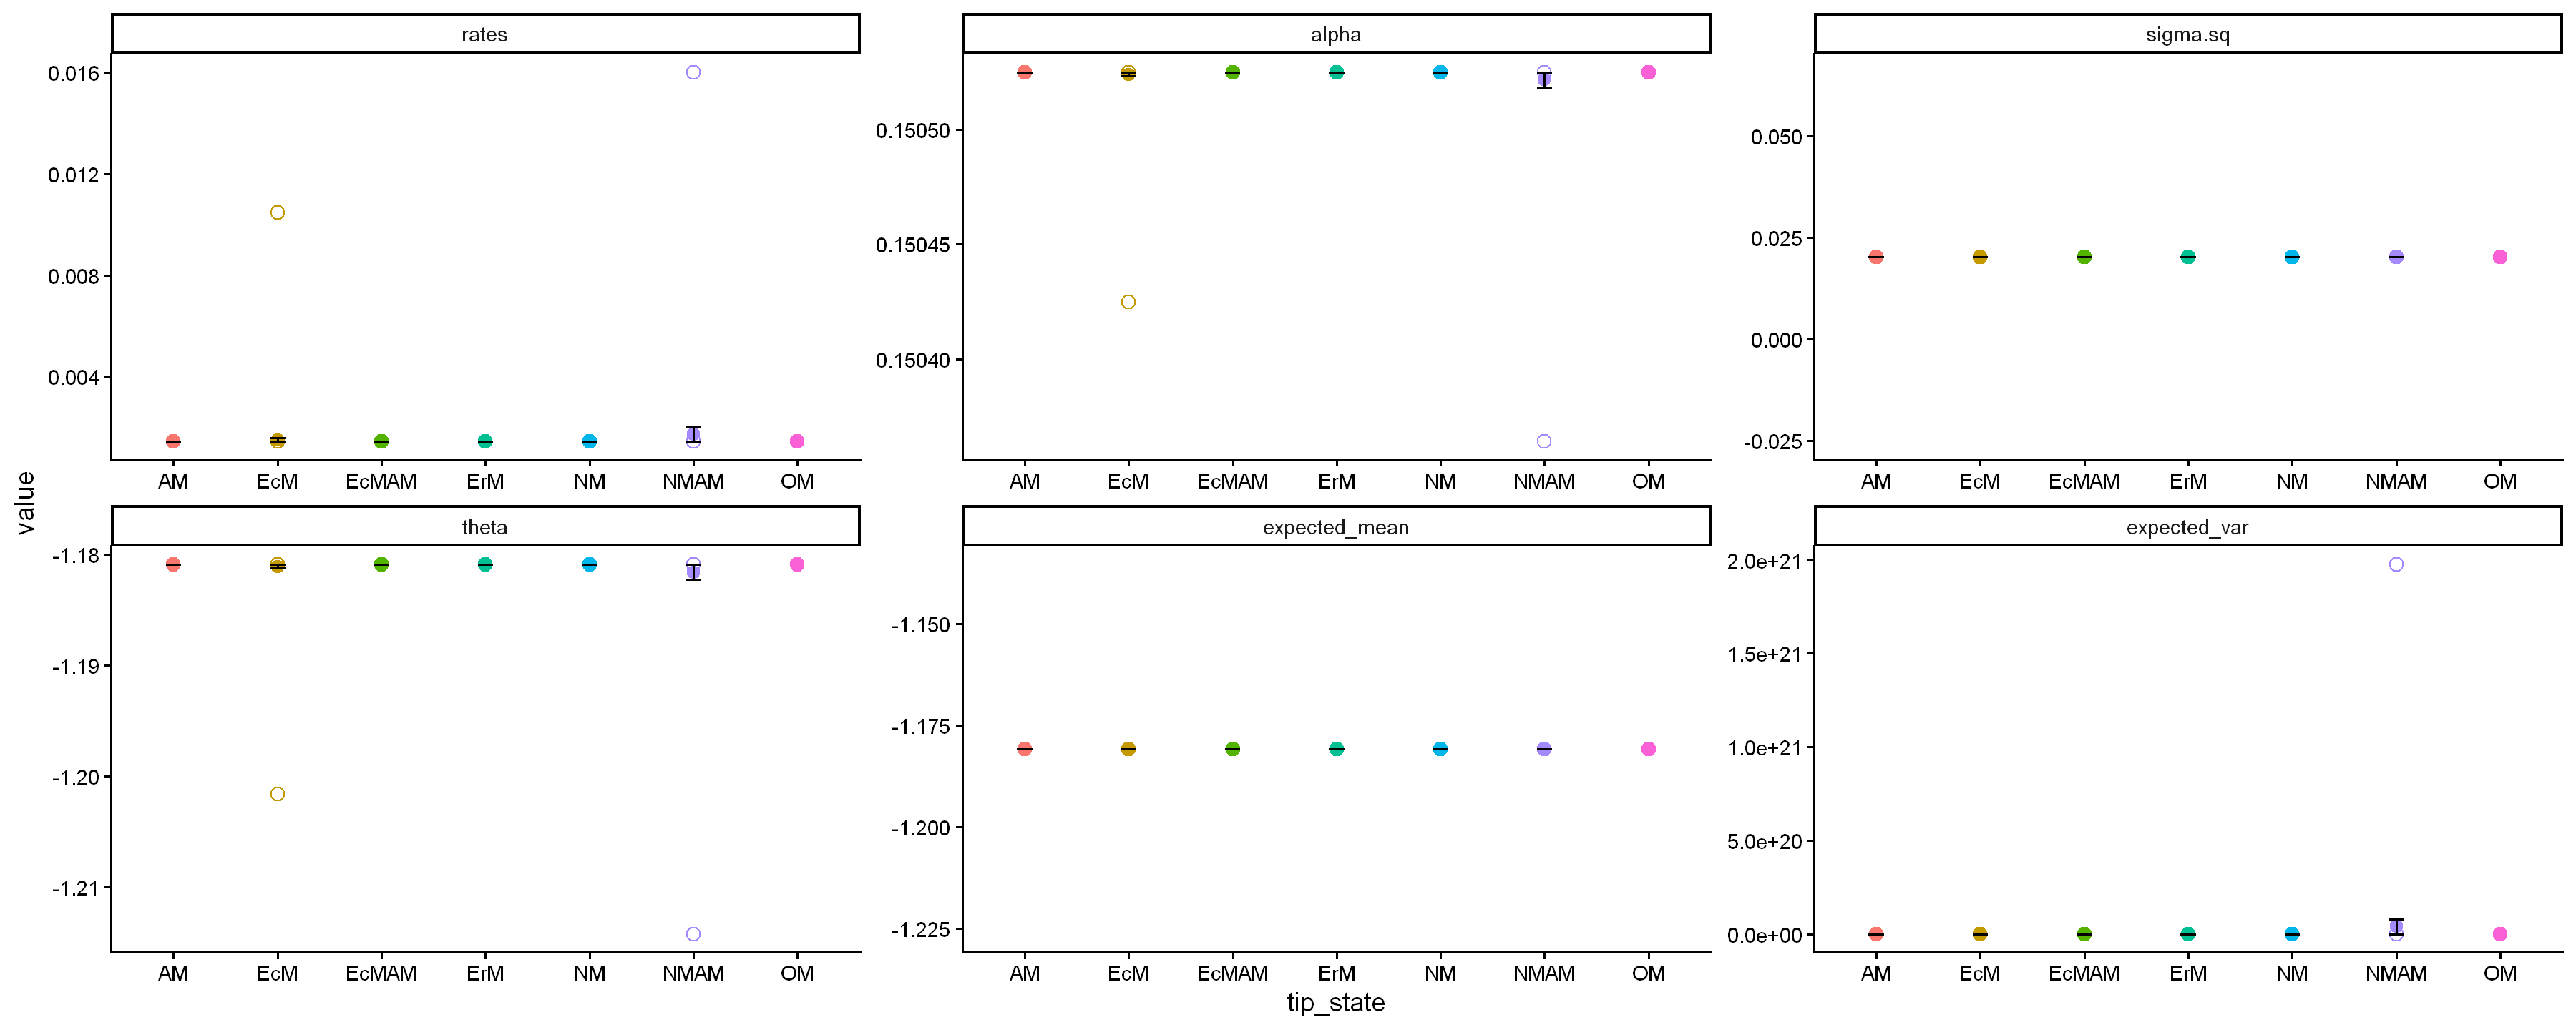

In [12]:
plot_df <- reshape2::melt(avg_models_CID_logSRL_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + 
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [5]:
#------------------------------------------------------------------------------------------------------------------------------------
# SPECIFIC ROOT LENGTH (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 4 MYCORRHIZAL STATES (ErM and OM removed & NM and AM/NM combined together)
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_SRL_994sp <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_4/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_SRL_994sp <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_4/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logSRL_994sp <- OUwie::getModelAvgParams(models_CD_log_SRL_994sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logSRL_994sp <- OUwie::getModelAvgParams(models_CID_log_SRL_994sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_SRL_994sp, type = "AICc")
OUwie::getModelTable(models_CID_log_SRL_994sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,18,-1789.832,-120.2521,-1666.212,3616.365,22.59561,1.239449e-05
ARDOUMA,21,-2076.276,-128.6939,-1944.902,4195.503,601.73395,2.162401e-131
ARDOUMV,21,-2117.741,-120.2551,-1994.637,4278.433,684.66349,2.123322e-149
ARDOUMVA,24,-2162.061,-172.1215,-3079.355,4373.360,779.59132,5.172488e-170
EROUM,7,-2151.589,-124.3172,-2023.883,4317.291,723.52209,7.744228e-158
EROUMA,10,-2042.882,-124.3727,-1863.120,4105.987,512.21821,5.929673e-112
EROUMV,10,-1786.773,-124.3217,-1660.408,3593.769,0.00000,9.995462e-01
EROUMVA,13,-2065.654,-124.3087,-1939.402,4157.680,563.91103,3.532472e-123
SYMOUM,12,-1792.451,-123.1201,-1667.628,3609.219,15.45004,4.414382e-04


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,30,-2.169476e+03,-151.5186,-2024.702,4.400883e+03,8589879768,0
ARDOUMA,31,-2.075581e+03,-167.7209,-1934.300,4.215224e+03,8589879582,0
ARDOUMV,31,-2.108700e+03,-155.0258,-1967.581,4.281463e+03,8589879649,0
ARDOUMVA,32,-1.999089e+03,-145.0697,-1878.183,4.064375e+03,8589879432,0
EROUM,8,-1.800561e+03,-124.3329,-1673.397,3.617269e+03,8589878984,0
EROUMA,9,-2.035820e+03,-143.8356,-1917.483,4.089824e+03,8589879457,0
EROUMV,9,-2.151794e+03,-124.5554,-2025.089,4.321770e+03,8589879689,0
EROUMVA,10,4.294938e+09,-124.5132,-2081.099,-8.589875e+09,0,1
SYMOUM,18,-2.150417e+03,-123.2386,-2023.887,4.337537e+03,8589879705,0


Using tip_state as id variables



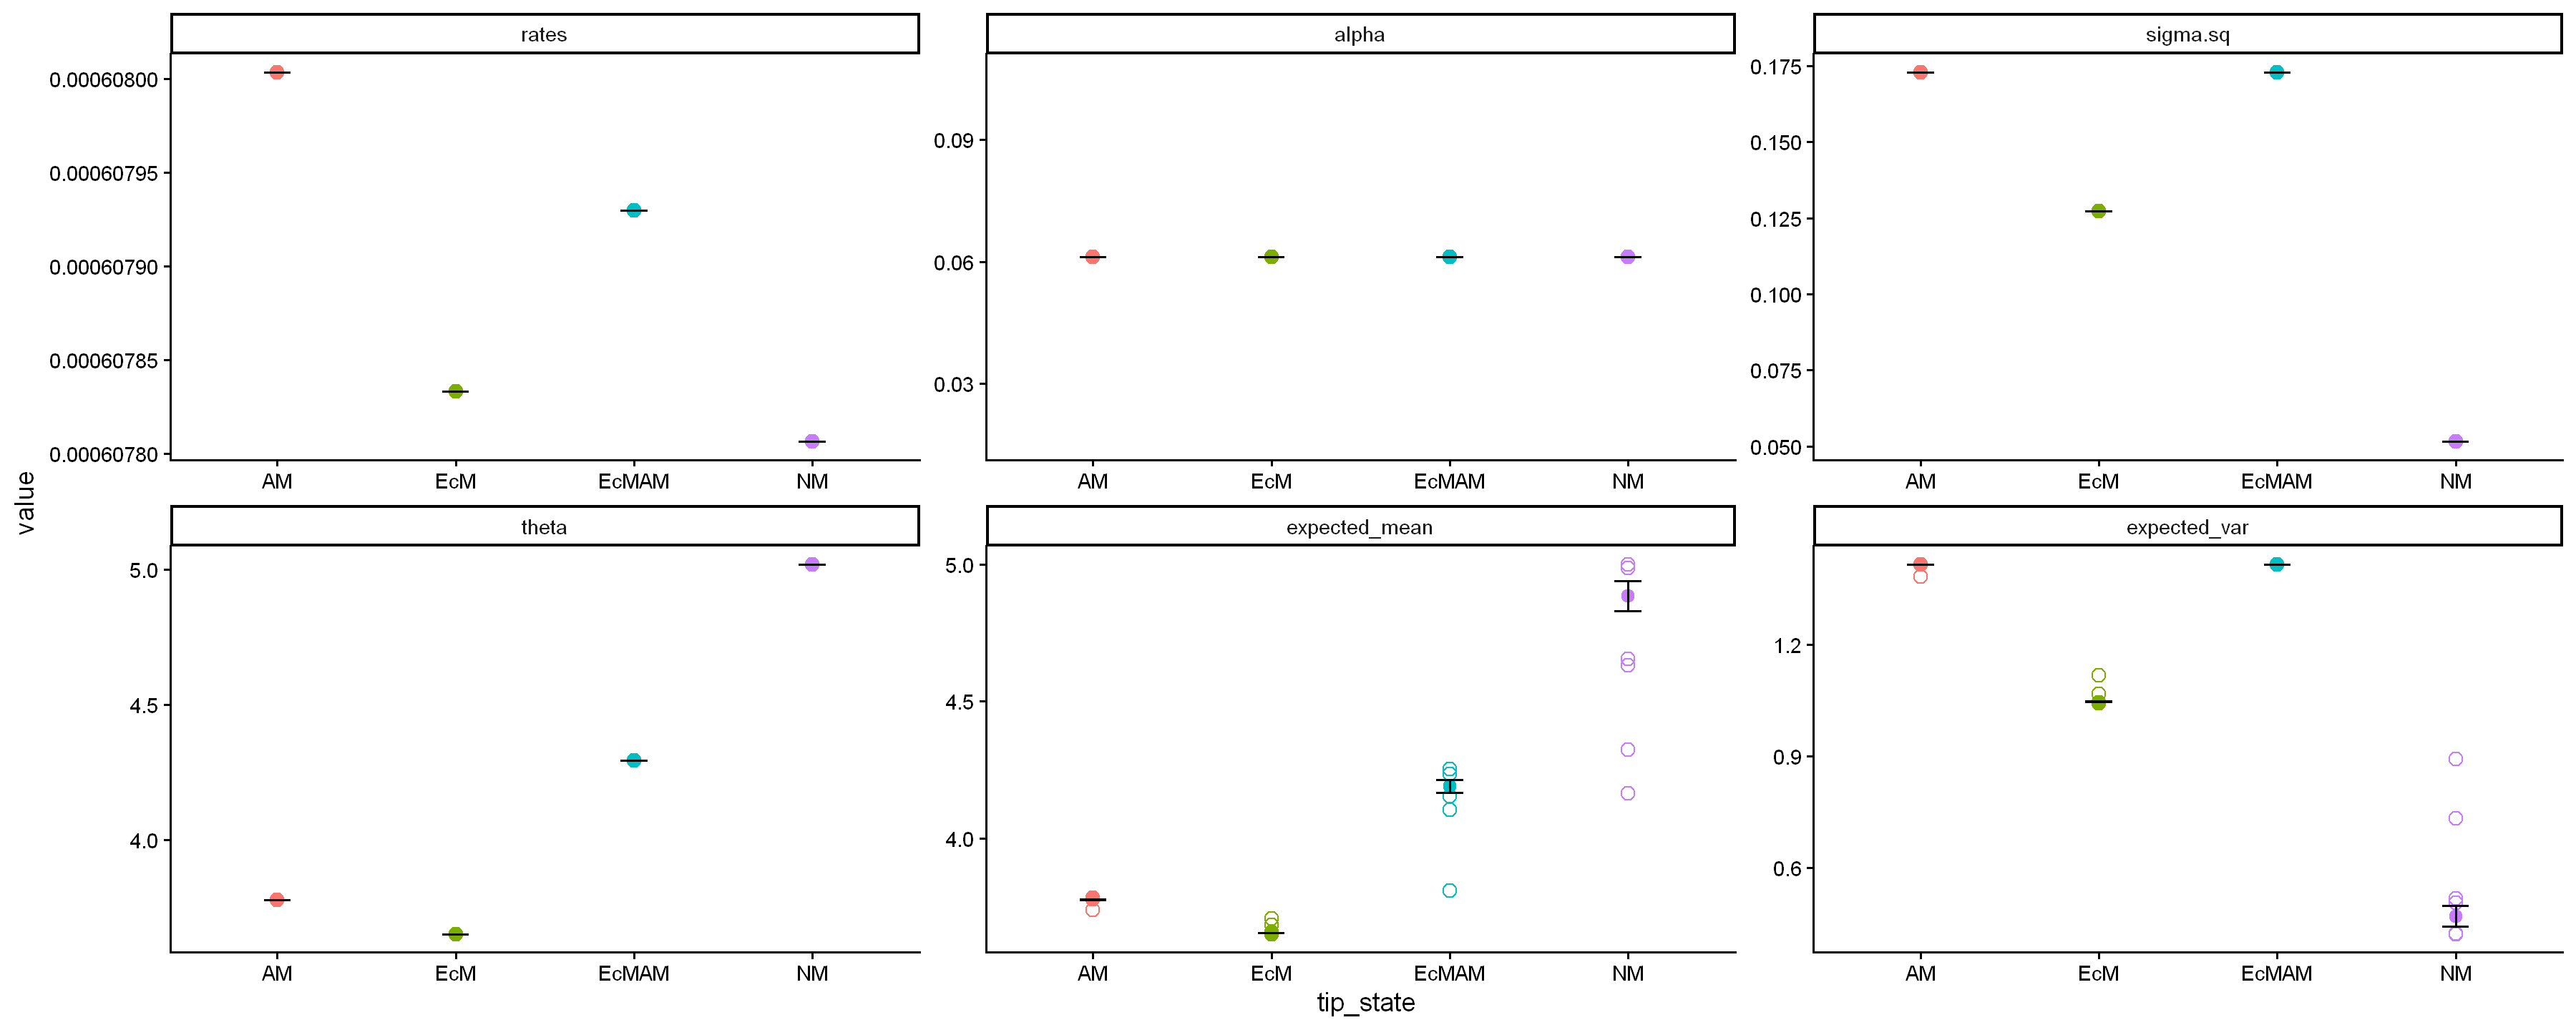

In [13]:
plot_df <- reshape2::melt(avg_models_CD_logSRL_994sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



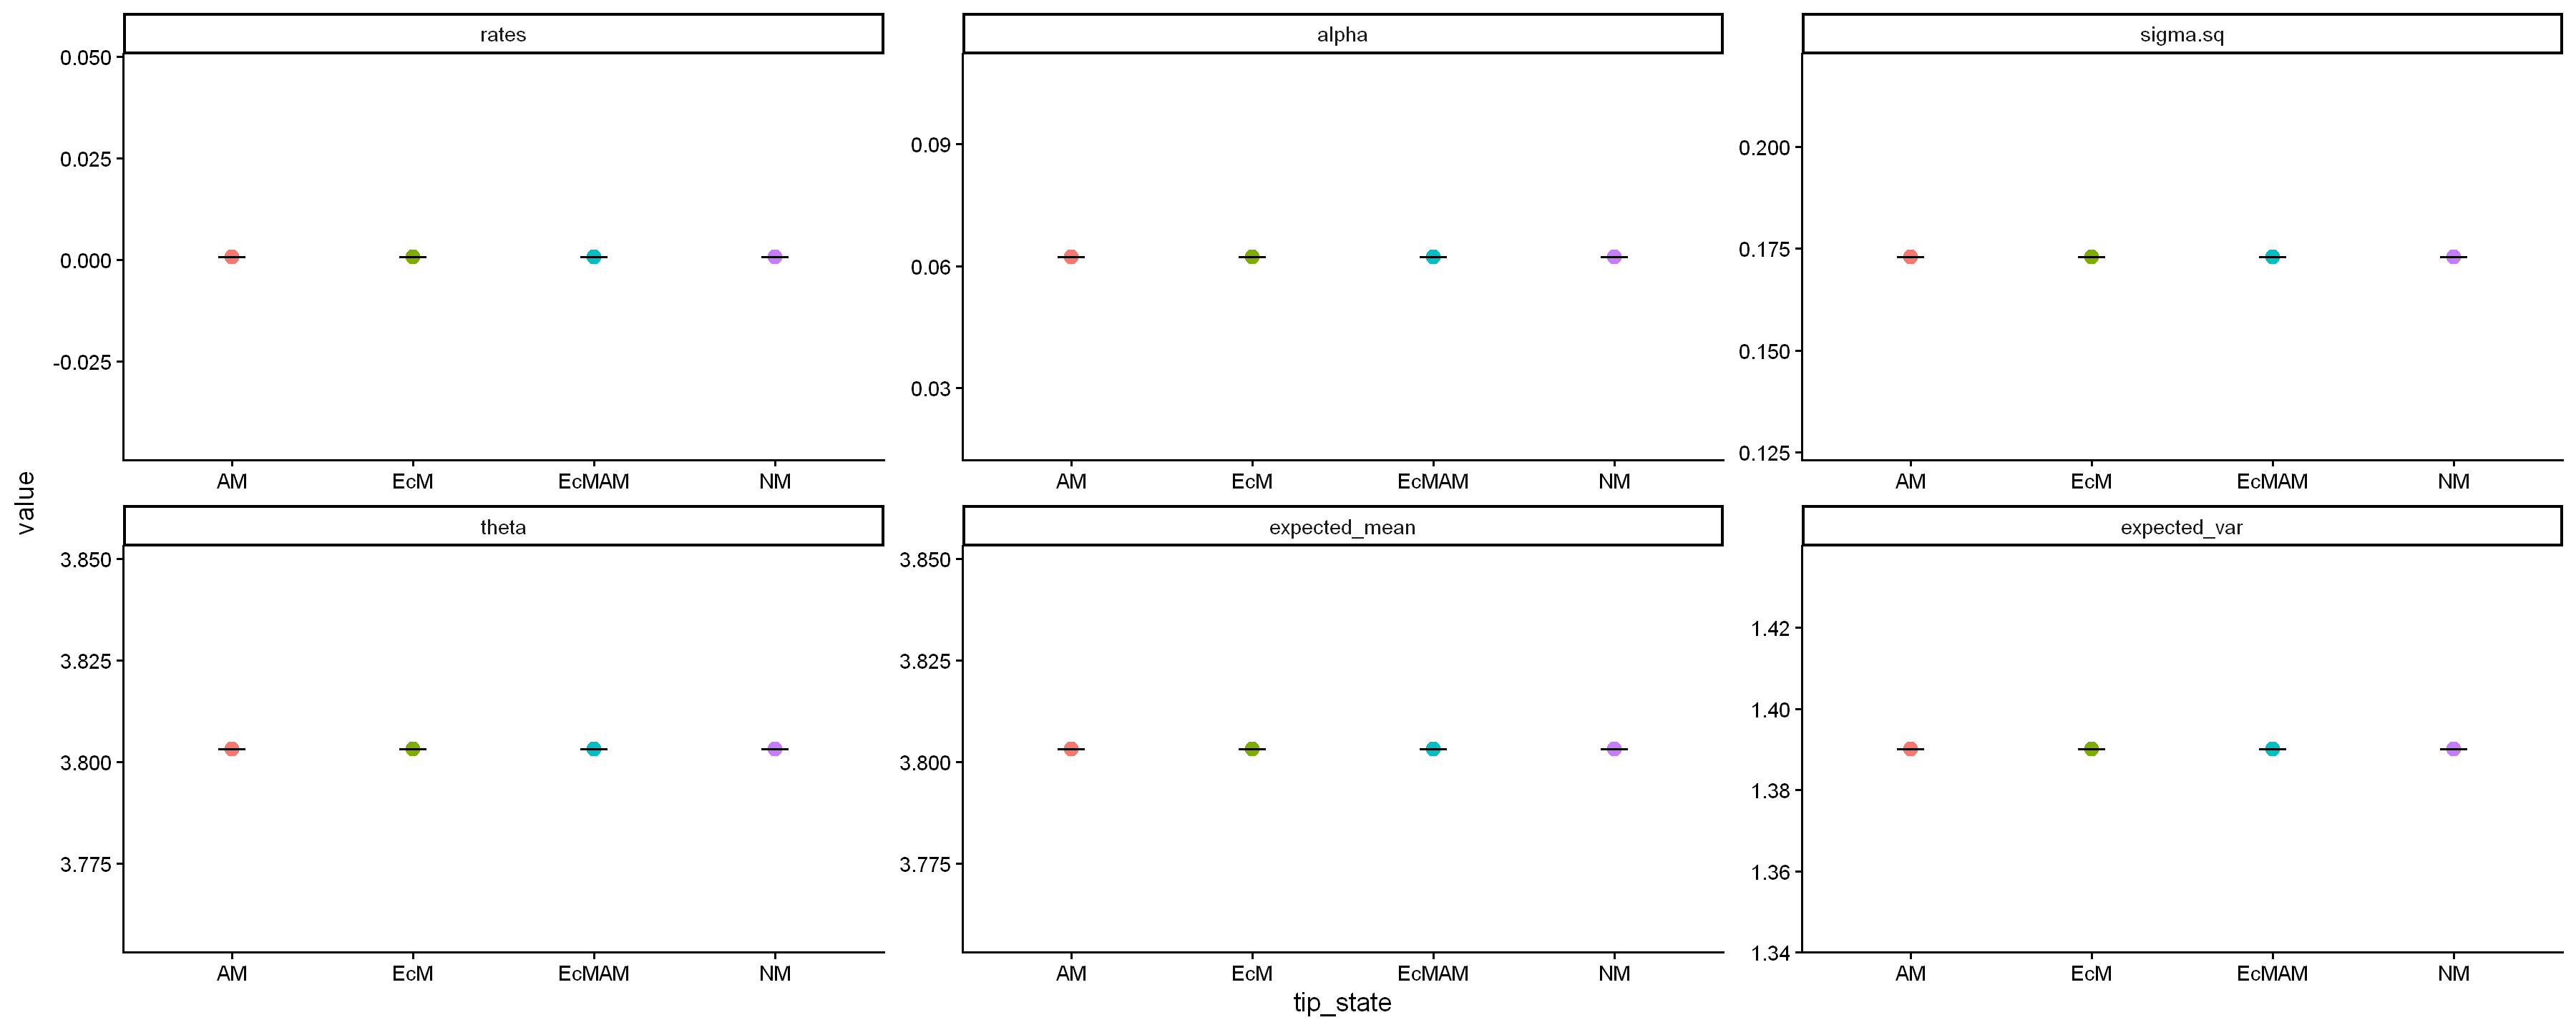

In [14]:
plot_df <- reshape2::melt(avg_models_CID_logSRL_994sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [10]:
#------------------------------------------------------------------------------------------------------------------------------------
# SPECIFIC ROOT LENGTH (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
# WITH 5 MYCORRHIZAL STATES (ErM and OM removed)
#------------------------------------------------------------------------------------------------------------------------------------

models_CD_log_SRL_994sp_5 <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = TRUE, regstrip = "_CD.Rds")
models_CID_log_SRL_994sp_5 <- readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = FALSE, regstrip = "_CID.Rds")

capture.output(avg_models_CD_logSRL_994sp_5 <- OUwie::getModelAvgParams(models_CD_log_SRL_994sp_5, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logSRL_994sp_5 <- OUwie::getModelAvgParams(models_CID_log_SRL_994sp_5, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_SRL_994sp_5, type = "AICc")
OUwie::getModelTable(models_CID_log_SRL_994sp_5, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-2250.020,-222.8615,-2024.546,4555.605,734.2851,3.564605e-160
ARDOUMA,31,-2225.721,-224.1159,-1997.389,4515.504,694.1833,1.819721e-151
ARDOUMV,31,-2220.185,-222.8419,-1994.823,4504.431,683.1112,4.616323e-149
ARDOUMVA,35,-2169.488,-225.8328,-1938.018,4411.606,590.2856,6.623942e-129
EROUM,8,-2260.291,-236.0052,-2021.127,4536.729,715.4086,4.477005e-156
EROUMA,12,-2254.986,-236.0390,-2039.651,4534.290,712.9697,1.515674e-155
EROUMV,12,-2233.516,-236.0289,-1994.209,4491.349,670.0288,3.199607e-146
EROUMVA,16,-15775.603,-331.4087,-14354.039,31583.763,27762.4429,0.000000e+00
SYMOUM,17,-1893.347,-225.9259,-1664.086,3821.320,0.0000,1.000000e+00


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-2271.234,-244.7590,-2023.896,4.639033e+03,536871420,0
ARDOUMA,47,-2231.176,-246.5935,-2034.991,4.561122e+03,536871343,0
ARDOUMV,47,-2262.437,-245.8775,-2013.580,4.623643e+03,536871405,0
ARDOUMVA,48,-2218.048,-245.3640,-2026.060,4.537073e+03,536871318,0
EROUM,8,-2263.320,-235.9985,-2023.926,4.542786e+03,536871324,0
EROUMA,9,268433399.782,-236.4739,-1629.887,-5.368668e+08,0,1
EROUMV,9,-2263.293,-236.0291,-2023.940,4.544769e+03,536871326,0
EROUMVA,10,-2173.435,-258.0234,-2038.879,4.367094e+03,536871148,0
SYMOUM,26,-2273.854,-250.0846,-2023.887,4.601160e+03,536871383,0


Using tip_state as id variables



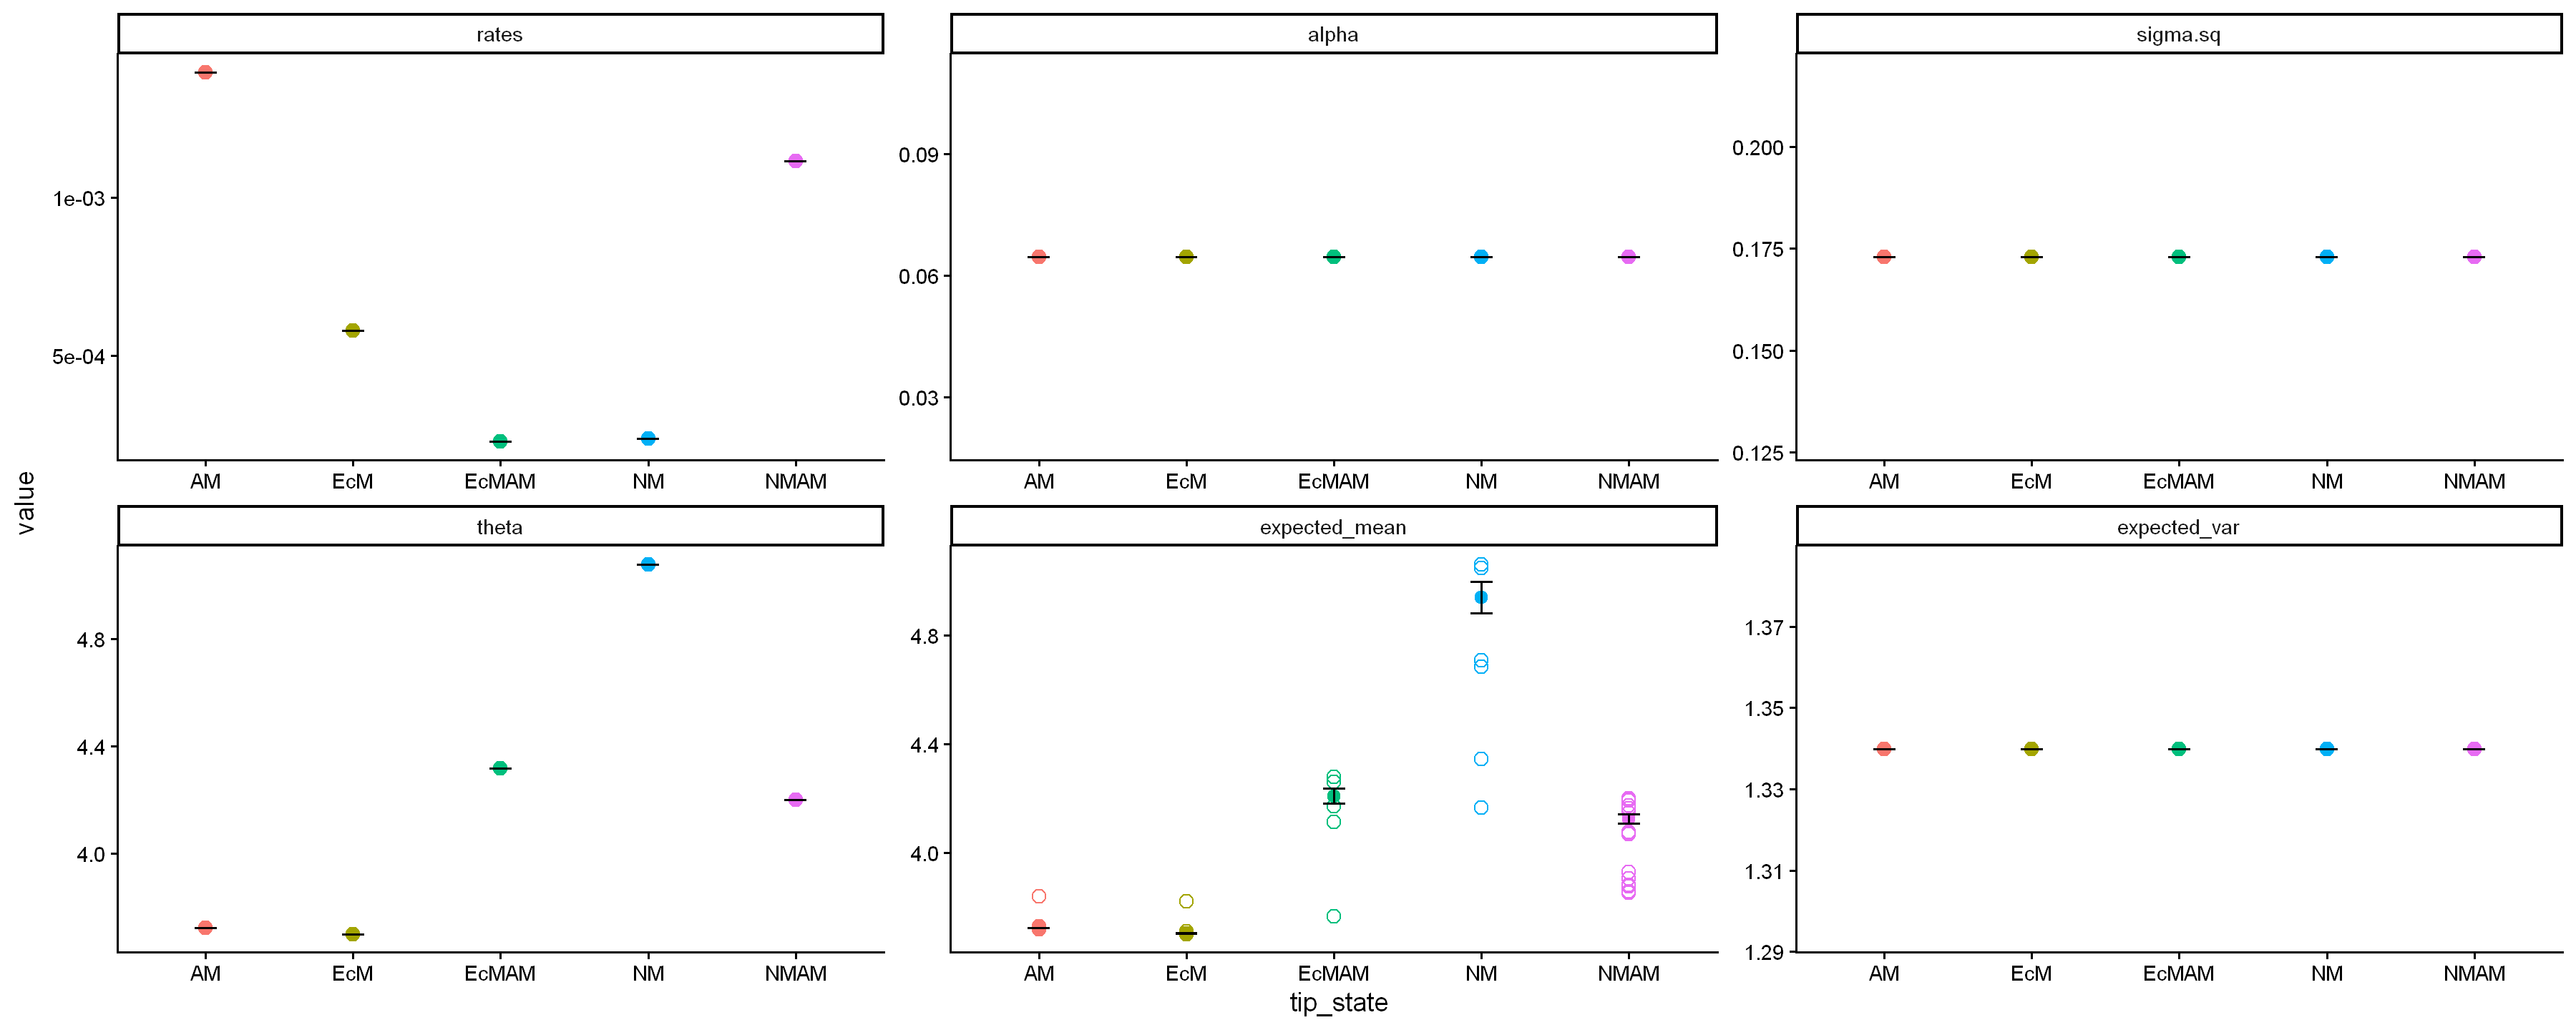

In [11]:
plot_df <- reshape2::melt(avg_models_CD_logSRL_994sp_5)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

Using tip_state as id variables



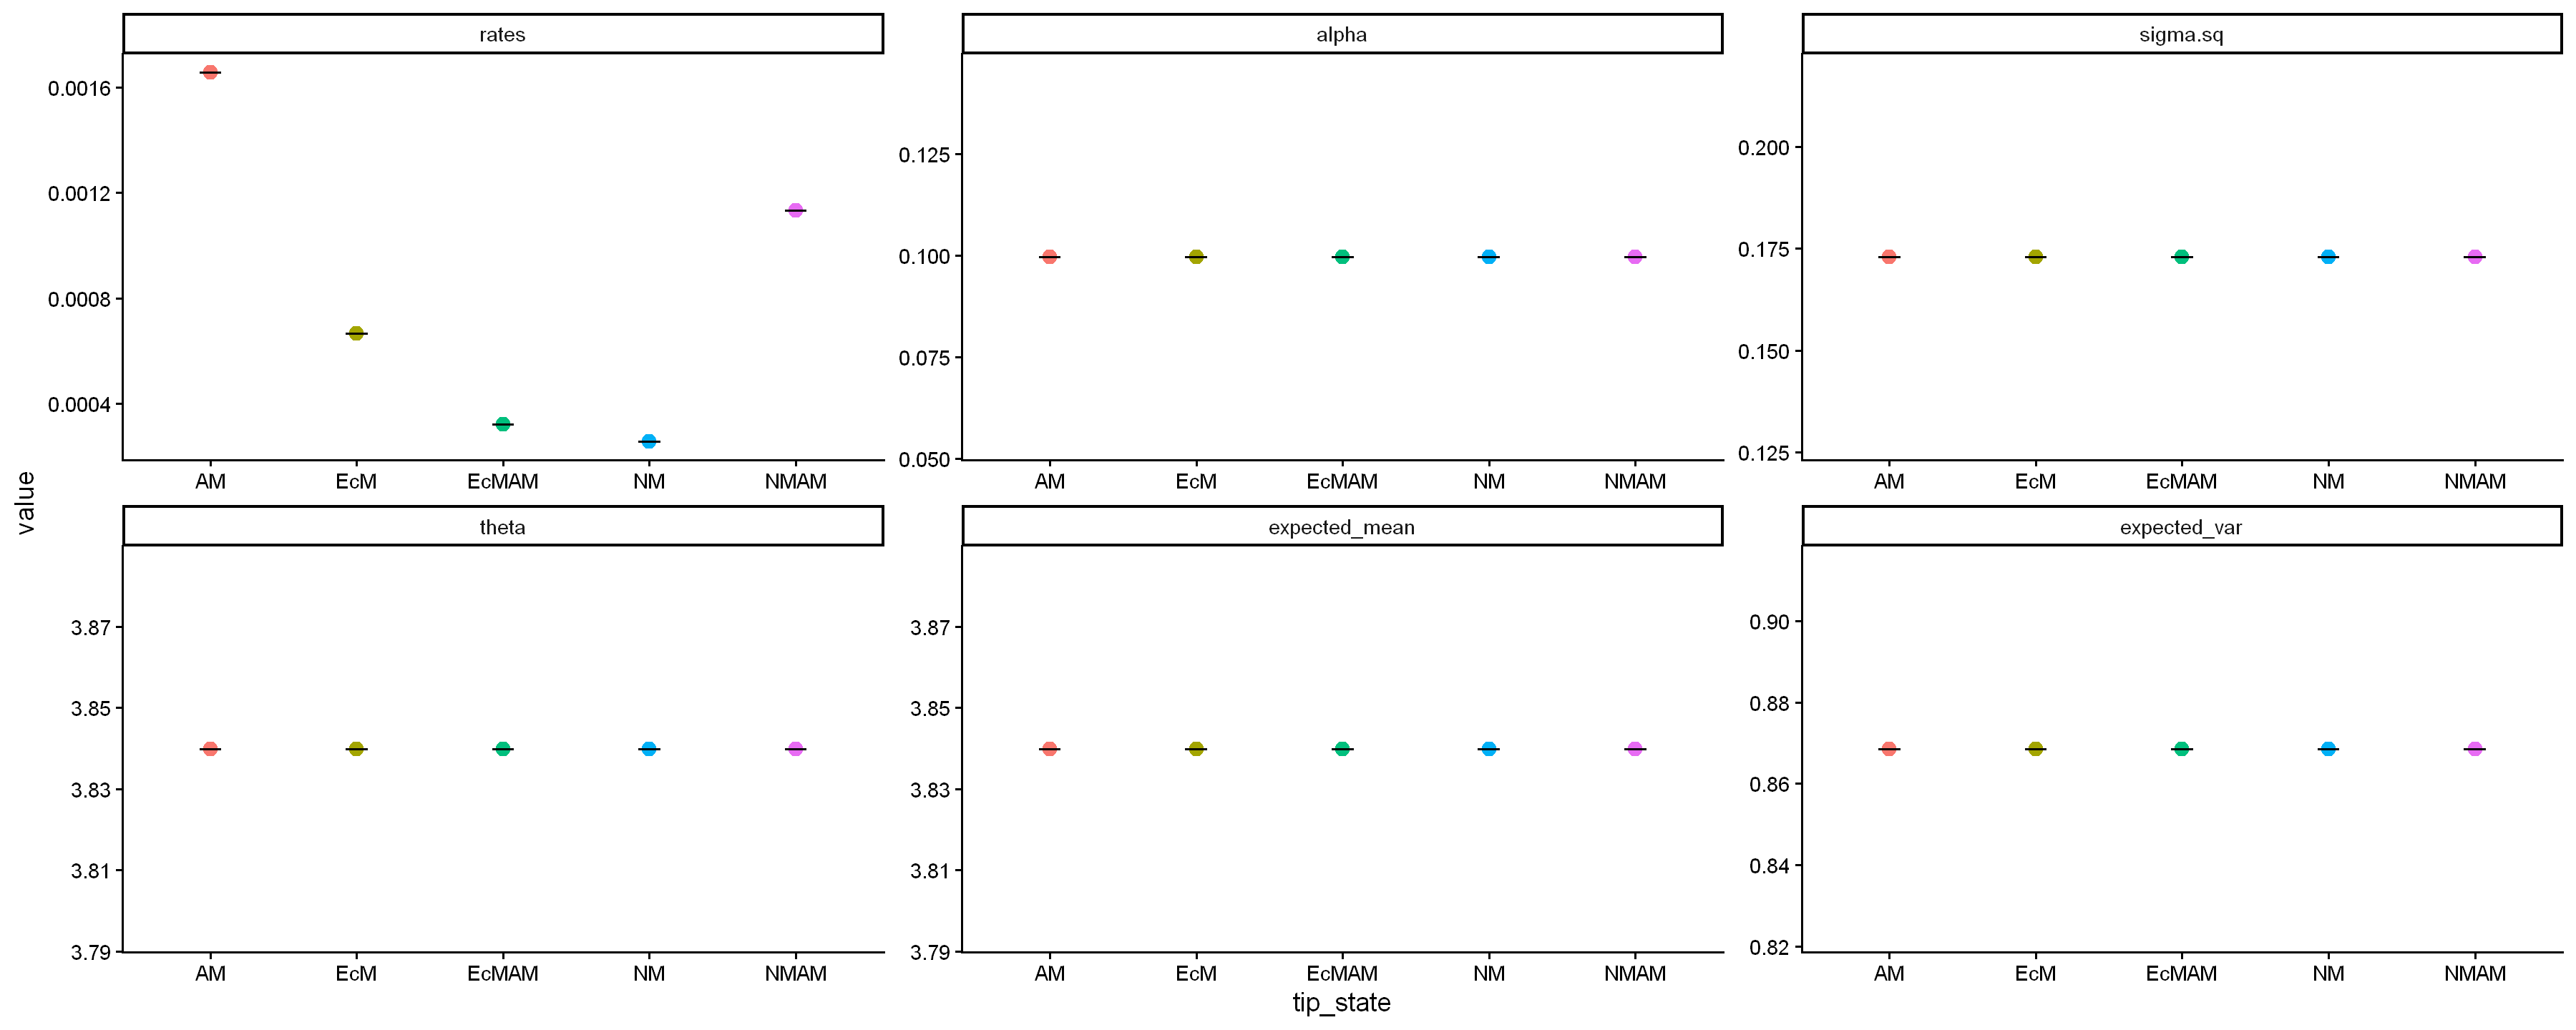

In [13]:
plot_df <- reshape2::melt(avg_models_CID_logSRL_994sp_5)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)